# Visualize Sam's data

# Importations

In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns
from scipy.optimize import curve_fit
from scipy import signal
import glob
from math import sqrt

In [2]:
%matplotlib inline

import matplotlib.pyplot as plt

from matplotlib import rc
import matplotlib.colors as mplcolors
from mpltools import annotation

rc('lines', linewidth=1.5, markeredgecolor='k', markeredgewidth=0.5)
rc('xtick', direction='in', labelsize=9)
rc('ytick', direction='in', labelsize=9)

rc('font', family='serif', size=9)
rc('text', usetex=True)

rc('figure', dpi=200)
rc('savefig', dpi=600)

# Auxiliary functions

In [3]:
# Cheat codes

In [4]:
def str2var(string):
    return globals()[string]

In [5]:
# I/O tasks

In [6]:
def sort_B_power(name: str, string: str ='rotation_data_1Hz_'):
    res = name[name.find(string)+len(string):]
    res = res[:res.find('_')]
    res = float(res)
    return res

def folderpath2filepaths(folderpath: str, string: str ='*.csv', sorting_key: None|function=None):
    filepaths = glob.glob(folderpath + string)
    if sorting_key is not None:
        filepaths.sort(key=sorting_key)
    return filepaths

def assemble_filepaths(folderpaths: list, string: str ='*.csv', sorting_key: None|function=None):
    res = []
    for folderpath in folderpaths:
        res = res + folderpath2filepaths(folderpath, string=string, sorting_key=None)
    res.sort(key=sorting_key)
    return res

def choose_condition(folderpaths, string):
    return [folderpath + string for folderpath in folderpaths]



In [7]:
# Data processing

In [8]:
def dedrift(x, method='detrend'):
    if method == 'detrend':
        res = signal.detrend(x, type='linear')
    else: 
        res = x
    return res

def moving_mean(x, window=1000):
    res = np.empty_like(x)
    N = len(x)
    half = int(np.ceil(window / 2))
    for i in range(N):
        if i < half:
            beg = 0
        else:
            beg = i - half
        if i > N - half:
            end = N
        else:
            end = i + half
        res[i] = np.nanmean(x[beg:end])
    return res

def remove_fake_jumps(x, threshold=100, period=360):
    res = np.copy(x)
    indices = np.abs(x[1:] - x[:-1]) > threshold
    indices = np.concatenate((np.array([False]), indices))
    res[indices] = np.nan
    # res[indices] = 360 - res[indices]
    # res[~np.isnan(res)] = np.unwrap(res[~np.isnan(res)], period=np.pi)
    res[indices] = res[indices] + np.sign(res[indices]) * period
    return res

In [9]:
# Compute observables

In [10]:
def moment(x: np.ndarray, delta: np.ndarray=np.arange(1,10,1), n: int|float=2, retrieve_mean: bool=False, fake_jumps=False):
    '''
    Moment (order n) of the variable x, for the time steps delta (differences of indexes).
    '''
    res = np.full(len(delta), np.nan)
    for i, d in enumerate(delta):
        dx = x[d:] - x[:-d]
        if fake_jumps:
            dx = remove_fake_jumps(dx, threshold=90, period=360)
        else:
            pass
        if retrieve_mean:
            res[i] = np.nanmean((dx - np.nanmean(dx)) ** n)
        else:
            res[i] = np.nanmean((dx) ** n)
    return res



In [11]:
from math import comb

def moment_fft(x: np.ndarray, delta: np.ndarray = np.arange(1, 10, 1), 
               n: int | float = 2, 
               retrieve_mean: bool = False, fake_jumps: bool = False, 
               ):
    """
    FFT-based computation of structure function moments.
    
    For integer n, uses the convolution theorem to compute E[(x[t+d] - x[t])^n]
    efficiently. For non-integer n, falls back to direct computation.
    """

    # Non-integer n: direct method
    if n != int(n):
        return moment(x, delta, n, retrieve_mean, fake_jumps)

    N = len(x)
    res = np.zeros(len(delta), dtype=float)
    n_int = int(n)

    # Precompute FFTs of x^k for k = 0..n  (done ONCE, not per delta)
    size = 2 * N  # zero-pad to avoid circular wrap
    X_ffts = [np.fft.rfft(x ** k, n=size) for k in range(n_int + 1)]

    # Full cross-correlation for each power pair (j, n-j), evaluated at ALL lags at once
    # corr_full[j][d] = sum_t x[t+d]^j * x[t]^(n-j)
    corr_full = [np.fft.irfft(X_ffts[j] * np.conj(X_ffts[n_int - j])) for j in range(n_int + 1)]

    res = np.full(len(delta), np.nan)
    counts = N - np.asarray(delta, dtype=int)  # number of valid pairs per lag

    for i, d in enumerate(delta):
        d = int(d)
        if d >= N: continue
        c = counts[i]

        if retrieve_mean:
            mean_dx = (corr_full[1][d] - corr_full[0][d]) / c  # E[x[t+d]] - E[x[t]]
            # E[dx^m] for m = 0..n via binomial, then outer binomial around mean
            E_dx_pow = np.zeros(n_int + 1)
            for m in range(n_int + 1):
                E_dx_pow[m] = sum(
                    comb(m, j) * ((-1) ** (m - j)) * corr_full[j][d]
                    for j in range(m + 1)
                ) / c
            res[i] = sum(comb(n_int, m) * ((-mean_dx) ** (n_int - m)) * E_dx_pow[m]
                         for m in range(n_int + 1))
        else:
            res[i] = sum(
                comb(n_int, j) * ((-1) ** (n_int - j)) * corr_full[j][d]
                for j in range(n_int + 1)
            ) / c

    res = np.real(res)
    return res

In [12]:
def pdf(data, bins=10, density=True, range=None):
    pdf, bins_edge = np.histogram(
        data, 
        bins=bins, 
        density=density, 
        range=range, 
    )
    bins_center = (bins_edge[0:-1] + bins_edge[1:]) / 2
    return pdf, bins_center

In [13]:
# Theoretical functions

In [14]:
def gaussian(x, a, b):
    return b * np.exp(- x ** 2 / (2 * a ** 2))

def gaussian_brownian(x, D, t):
    # return gaussian(x, np.sqrt(2*D*t), 1/np.sqrt(4*np.pi*D*t))
    return 1 / np.sqrt(4 * np.pi * D * t) * np.exp(- x ** 2 / (4 * D * t))

# Info on files

In [15]:
glob.glob('../sam/shell_stuck_on_surface/TriAmineChip2/*')

['../sam/shell_stuck_on_surface/TriAmineChip2/position1_neutral_pH_start',
 '../sam/shell_stuck_on_surface/TriAmineChip2/position1_NaOH_1e-3',
 '../sam/shell_stuck_on_surface/TriAmineChip2/position1_NaOH_10-5_NaCl_10-4',
 '../sam/shell_stuck_on_surface/TriAmineChip2/position1_NaOH_1e-5',
 '../sam/shell_stuck_on_surface/TriAmineChip2/position1_NaOH_10-5_NaCl_10-3']

In [16]:
glob.glob('../sam/shell_stuck_on_surface/TriAmineChip3/*')

['../sam/shell_stuck_on_surface/TriAmineChip3/position1_NaOH_2_going_back_from_salt',
 '../sam/shell_stuck_on_surface/TriAmineChip3/position2_NaOH_2_going_back_from_salt',
 '../sam/shell_stuck_on_surface/TriAmineChip3/position2_NaOH_10-5_NaCl_10-3',
 '../sam/shell_stuck_on_surface/TriAmineChip3/position3_NaOH_10-5_NaCl_10-3',
 '../sam/shell_stuck_on_surface/TriAmineChip3/position1_NaOH_1e-5',
 '../sam/shell_stuck_on_surface/TriAmineChip3/position3_NaOH_2_going_back_from_salt',
 '../sam/shell_stuck_on_surface/TriAmineChip3/position1_NaOH_10-5_NaCl_10-3']

# Load data

In [17]:
# One experimental condition

folderpaths_0 = [
    '../sam/shell_stuck_on_surface/TriAmineChip2/position1_NaOH_10-5_NaCl_10-3/', 
    '../sam/shell_stuck_on_surface/TriAmineChip3/position1_NaOH_10-5_NaCl_10-3/', 
    '../sam/shell_stuck_on_surface/TriAmineChip3/position2_NaOH_10-5_NaCl_10-3/', 
    '../sam/shell_stuck_on_surface/TriAmineChip3/position3_NaOH_10-5_NaCl_10-3/', 
]

# DO NOT FORGET THE LAST / IN THE FILE PATHS ABOVE

folderpaths_0_1 = choose_condition(folderpaths_0, string='1.0Hz/')
filepaths_0_1 = assemble_filepaths(folderpaths_0_1, string='*.csv', sorting_key=sort_B_power)

folderpaths_0_0 = choose_condition(folderpaths_0, string='0.0Hz/')
filepaths_0_0 = assemble_filepaths(folderpaths_0_0, string='*.csv', sorting_key=None)[:]

filepaths_0_0

['../sam/shell_stuck_on_surface/TriAmineChip2/position1_NaOH_10-5_NaCl_10-3/0.0Hz/rotation_data_0Hz_0_0_particle_1.csv',
 '../sam/shell_stuck_on_surface/TriAmineChip3/position1_NaOH_10-5_NaCl_10-3/0.0Hz/rotation_data_0Hz_0_0_2_particle_1.csv',
 '../sam/shell_stuck_on_surface/TriAmineChip3/position1_NaOH_10-5_NaCl_10-3/0.0Hz/rotation_data_0Hz_0_0_2_particle_2.csv',
 '../sam/shell_stuck_on_surface/TriAmineChip3/position1_NaOH_10-5_NaCl_10-3/0.0Hz/rotation_data_0Hz_0_0_particle_1.csv',
 '../sam/shell_stuck_on_surface/TriAmineChip3/position1_NaOH_10-5_NaCl_10-3/0.0Hz/rotation_data_0Hz_0_0_particle_2.csv',
 '../sam/shell_stuck_on_surface/TriAmineChip3/position2_NaOH_10-5_NaCl_10-3/0.0Hz/rotation_data_0Hz_0_0_particle_1.csv',
 '../sam/shell_stuck_on_surface/TriAmineChip3/position2_NaOH_10-5_NaCl_10-3/0.0Hz/rotation_data_0Hz_0_0_particle_2.csv',
 '../sam/shell_stuck_on_surface/TriAmineChip3/position3_NaOH_10-5_NaCl_10-3/0.0Hz/rotation_data_0Hz_0_0_particle_1.csv',
 '../sam/shell_stuck_on_surf

In [18]:
# Another experimental condition

folderpaths_1 = [
    '../sam/shell_stuck_on_surface/TriAmineChip2/position1_NaOH_1e-5/',
    '../sam/shell_stuck_on_surface/TriAmineChip3/position1_NaOH_1e-5/',
]

folderpaths_1_1 = choose_condition(folderpaths_1, string='1.0Hz/')
filepaths_1_1 = assemble_filepaths(folderpaths_1_1, string='*.csv', sorting_key=sort_B_power)

folderpaths_1_0 = choose_condition(folderpaths_1, string='0.0Hz/')
filepaths_1_0 = assemble_filepaths(folderpaths_1_0, string='*.csv', sorting_key=None)

filepaths_1_0

['../sam/shell_stuck_on_surface/TriAmineChip2/position1_NaOH_1e-5/0.0Hz/rotation_data_0Hz_0_0_particle_1.csv',
 '../sam/shell_stuck_on_surface/TriAmineChip3/position1_NaOH_1e-5/0.0Hz/rotation_data_0Hz_0_0_particle_1.csv',
 '../sam/shell_stuck_on_surface/TriAmineChip3/position1_NaOH_1e-5/0.0Hz/rotation_data_0Hz_0_0_particle_2.csv']

In [19]:
folderpaths_2 = [
     '../sam/shell_stuck_on_surface/TriAmineChip2/position1_NaOH_10-5_NaCl_10-4/',
]

folderpaths_2_1 = choose_condition(folderpaths_2, string='1.0Hz/')
filepaths_2_1 = assemble_filepaths(folderpaths_2_1, string='*.csv', sorting_key=sort_B_power)

folderpaths_2_0 = choose_condition(folderpaths_2, string='0.0Hz/')
filepaths_2_0 = assemble_filepaths(folderpaths_2_0, string='*.csv', sorting_key=None)

filepaths_2_0 = filepaths_2_0[:]

filepaths_2_0

['../sam/shell_stuck_on_surface/TriAmineChip2/position1_NaOH_10-5_NaCl_10-4/0.0Hz/rotation_data_0Hz_0_0_particle_1.csv']

In [20]:
def return_filetpaths(folderpaths):
    f1 = choose_condition(folderpaths, string='1.0Hz/')
    res1 = assemble_filepaths(f1, string='*.csv', sorting_key=sort_B_power)
    f0 = choose_condition(folderpaths, string='0.0Hz/')
    res0 = assemble_filepaths(f0, string='*.csv', sorting_key=None)
    return res0, res1

In [21]:
folderpaths_3 = [
    '../sam/shell_stuck_on_surface/TriAmineChip3/position1_NaOH_2_going_back_from_salt/', 
    '../sam/shell_stuck_on_surface/TriAmineChip3/position2_NaOH_2_going_back_from_salt/', 
    '../sam/shell_stuck_on_surface/TriAmineChip3/position3_NaOH_2_going_back_from_salt/', 
]

filepaths_3_0, filepaths_3_1 = return_filetpaths(folderpaths_3)
filepaths_3_0

['../sam/shell_stuck_on_surface/TriAmineChip3/position1_NaOH_2_going_back_from_salt/0.0Hz/rotation_data_0Hz_0_0_particle_1.csv',
 '../sam/shell_stuck_on_surface/TriAmineChip3/position1_NaOH_2_going_back_from_salt/0.0Hz/rotation_data_0Hz_0_0_particle_2.csv',
 '../sam/shell_stuck_on_surface/TriAmineChip3/position2_NaOH_2_going_back_from_salt/0.0Hz/rotation_data_0Hz_0_0_particle_1.csv',
 '../sam/shell_stuck_on_surface/TriAmineChip3/position2_NaOH_2_going_back_from_salt/0.0Hz/rotation_data_0Hz_0_0_particle_2.csv',
 '../sam/shell_stuck_on_surface/TriAmineChip3/position3_NaOH_2_going_back_from_salt/0.0Hz/rotation_data_0Hz_0_0_particle_1.csv',
 '../sam/shell_stuck_on_surface/TriAmineChip3/position3_NaOH_2_going_back_from_salt/0.0Hz/rotation_data_0Hz_0_0_particle_2.csv']

In [22]:
folderpaths_4 = [
    '../sam/shell_stuck_on_surface/TriAmineChip2/position1_NaOH_1e-3/',
]

filepaths_4_0, filepaths_4_1 = return_filetpaths(folderpaths_4)
filepaths_4_0

['../sam/shell_stuck_on_surface/TriAmineChip2/position1_NaOH_1e-3/0.0Hz/rotation_data_0Hz_0_0_particle_1.csv']

In [23]:
folderpaths_5 = [
    '../sam/shell_stuck_on_surface/TriAmineChip2/position1_neutral_pH_start/',
]

filepaths_5_0, filepaths_5_1 = return_filetpaths(folderpaths_5)
filepaths_5_0

['../sam/shell_stuck_on_surface/TriAmineChip2/position1_neutral_pH_start/0.0Hz/rotation_data_0Hz_0_0_particle_1.csv']

In [26]:
folderpaths_6 = [
    '../data/2026/20260806_StuckRattler/water/', 
    '../data/2026/20260806_StuckRattler/water_PEG_0p1/', 
]

filepaths_6 = [glob.glob(path + 'traj*') for path in folderpaths_6]
filepaths_6

[['../data/2026/20260806_StuckRattler/water/trajectories_20260806115012484',
  '../data/2026/20260806_StuckRattler/water/trajectories_20260806114926416',
  '../data/2026/20260806_StuckRattler/water/trajectories_20260806115119182'],
 ['../data/2026/20260806_StuckRattler/water_PEG_0p1/trajectories_20260806144055387',
  '../data/2026/20260806_StuckRattler/water_PEG_0p1/trajectories_20260806144826130',
  '../data/2026/20260806_StuckRattler/water_PEG_0p1/trajectories_20260806144300861']]

In [24]:
# Calib 

calib = 35e-9

# Calib to be checked ! 

In [25]:
df = pd.read_csv(filepaths_0_0[0])
df.head()

,frame,time_sec,principal_angle_deg,principal_angle_180_deg,principal_angle_360_deg,delta_angle_deg,cumulative_rotation_deg,delta_angle_deg_180,cumulative_rotation_deg_180,com_x_px,com_y_px
0,0,0.000,74.621361,74.621361,164.621361,0.000000,0.000000,0.000000,0.000000,101.702299,85.310755
1,1,0.001,74.954231,74.954231,164.954231,0.332870,0.332870,0.332870,0.332870,101.725506,85.310158
2,2,0.002,75.938057,75.938057,165.938057,0.983826,1.316696,0.983826,1.316696,101.726406,85.311828
3,3,0.003,75.977646,75.977646,165.977646,0.039589,1.356285,0.039589,1.356285,101.722519,85.310437
4,4,0.004,75.871994,75.871994,165.871994,-0.105652,1.250633,-0.105652,1.250633,101.725281,85.311007


In [26]:
del df

In [27]:
# fig = plt.figure(figsize=(20/2.54, 6/2.54))

# ax1 = fig.add_subplot(1, 5, (1,2))
# ax2 = fig.add_subplot(1, 5, (3,5))

# for i, k in enumerate(indexes):
    
#     theta = datas[:, 3, k]

#     where = theta > 350
#     thetam = np.copy(theta)
#     thetam[where] = theta[where] - 360

#     prob, bins = pdf(thetam, bins=36)
#     prob = prob / np.trapezoid(prob, bins)

#     ax1.plot(bins, prob, ls='-', color=colors[k], lw=1)

#     # Recentering theta
#     thetab = thetam - np.nanmean(bins[prob == np.max(prob)])
#     prob, bins = pdf(thetab[np.abs(thetab) < 15], bins=36)
#     prob = prob / np.trapezoid(prob, bins)

#     ax2.plot(bins, prob, ls='', marker='o', color=colors[k], mew=0.2)

#     popt, _ = curve_fit(gaussian, bins, prob, p0=[1,1])
#     ax2.plot(bins, gaussian(bins, *popt), ls='-', color=colors[k])
    
#     print(popt)
#     print(4e-21 / abs(popt[0]))
#     print()

# ax1.set_ylabel(r'$P(\theta)$ (a.u.)')
# for ax in [ax1, ax2]:
#     ax.set_xlabel(r'$\theta$ (°)')
#     # ax.set_xscale('log')
#     ax.set_yscale('log')

# plt.tight_layout()
# plt.show()

In [28]:
def create_datas(filepaths, calib):
    Ns = np.zeros(len(filepaths), dtype=int)
    dts = np.zeros(len(filepaths), dtype=float)

    for i, path in enumerate(filepaths):
        df = pd.read_csv(path)
        # Number of frames
        Ns[i] = int(len(df['frame']))
        # Frame rate / time step
        time = df['time_sec'].to_numpy()
        dt = np.nanmean(time[1:] - time[:-1])
        dt = np.round(dt, 4)
        dts[i] = dt
    
    print('Length of the shortest trajectory:')
    print(min(Ns))

    print()
    print('Time step (in s) of all the trajectories:')
    print(dts)
    
    Ntime = min(Ns)
    Ntraj = len(filepaths)
    datas = np.zeros((Ntime, 4, Ntraj))
    
    for i, path in enumerate(filepaths):
        df = pd.read_csv(path)
        df = df[:Ntime]
        time = df['time_sec'].to_numpy()
        # theta1 = df['principal_angle_deg'].to_numpy()
        # theta2 = df['principal_angle_180_deg'].to_numpy()
        xpx = df['com_x_px'].to_numpy()
        ypx = df['com_y_px'].to_numpy()
        x = xpx * calib
        y = ypx * calib
        theta3 = df['principal_angle_360_deg'].to_numpy()
        datas[:,0,i] = np.copy(time)
        # datas[:,1,i] = np.copy(theta1)
        # datas[:,2,i] = np.copy(theta2)
        datas[:,1,i] = np.copy(x)
        datas[:,2,i] = np.copy(y)
        datas[:,3,i] = np.copy(theta3)

    del df, time, xpx, ypx, theta3

    return datas, Ns, dts, Ntime, Ntraj

In [29]:
def compute_pdf(dx : np.ndarray, cutoff : float = 10, bins : int|np.ndarray = 30, normalize: bool = True):
    sample = dx[np.abs(dx) < cutoff]
    prob, bins = pdf(sample[~np.isnan(sample)], bins=bins)
    if normalize:
        prob = prob / np.trapezoid(prob, bins)
    return prob, bins

In [30]:
class Observables():

    def __init__(
            self, 
            filepaths, 
            calib, 
            colors, colors_uniform, 
            dframes_msd=None, dframes_msd_theta=None, 
            #dframes_Pdx=np.array([1, 5, 10, 100, 1000]), dframes_Pdtheta=np.array([1, 5, 10, 100, 1000]), 
            window_dedrift=1, 
        ):
        self.filepaths = filepaths 
        self.colors = colors
        self.colors_uniform = colors_uniform

        datas, Ns, dts, Ntime, Ntraj = create_datas(self.filepaths, calib)
        self.datas = datas
        self.Ns = Ns
        self.dts = dts
        self.Ntime = Ntime
        self.Ntraj = Ntraj 

        self.dframes_msd = dframes_msd
        if self.dframes_msd == None: 
            self.dframes_msd = np.arange(1, self.Ntime - self.Ntime // 4)
        self.msds = np.zeros((len(self.dframes_msd), self.Ntraj), dtype=float)
        self.kurtosis = np.zeros((len(self.dframes_msd), self.Ntraj), dtype=float)

        self.dframes_msd_theta = dframes_msd_theta
        if self.dframes_msd_theta == None: 
            self.dframes_msd_theta = np.concatenate((np.arange(1, 100, 1), np.arange(100, 10000, 100)))
        self.msds_theta = np.zeros((len(self.dframes_msd_theta), self.Ntraj), dtype=float)

        self.m1rs = np.zeros((len(self.dframes_msd), self.Ntraj), dtype=float)
        self.m1thetas = np.zeros((len(self.dframes_msd_theta), self.Ntraj), dtype=float)

        # self.dframes_Pdx = dframes_Pdx
        # self.dframes_Pdtheta = dframes_Pdtheta

        self.Pdx = {}
        self.Pdthetas = {}

        self.window_dedrift = window_dedrift # s
        self.datac = np.copy(self.datas)

    
    def unravel_datas(self, ind):
        time = self.datas[:,0,ind]
        x = self.datas[:,1,ind]
        y = self.datas[:,2,ind]
        theta = self.datas[:,3,ind]
        timestep = self.dts[ind]
        return time, x, y, theta, timestep
    

    def unravel_datac(self, ind):
        time = self.datac[:,0,ind]
        x = self.datac[:,1,ind]
        y = self.datac[:,2,ind]
        theta = self.datac[:,3,ind]
        timestep = self.dts[ind]
        return time, x, y, theta, timestep
    

    def display_trajectories(self, n=None, dedrifts=True):
        if n == None:
            n = np.arange(self.Ntraj)
        fig, axes = plt.subplots(max([2, len(n)]), 3, figsize=(21/2.54, int(max([2, len(n)])*5)/2.54))
        for i, ind in enumerate(n):
            time, x, y, theta, _ = self.unravel_datas(ind)
            xsmooth, ysmooth, xd, yd = self.see_drifts(ind)
            # theta = remove_fake_jumps(theta, threshold=90, period=360)
            start = 0
            stop = len(time) #// 10
            axes[i, 0].plot(time[start:stop], x[start:stop] * 1e6, ls='-', color=self.colors[ind])
            axes[i, 0].plot(time[start:stop], xsmooth[start:stop] * 1e6, ls='-', lw=1, color='white')
            axes[i, 0].plot(time[start:stop], xd[start:stop] * 1e6 + np.nanmean(x) * 1e6, ls='-', color='k', alpha=0.6)
            axes[i, 1].plot(time[start:stop], y[start:stop] * 1e6, ls='-', color=self.colors[ind])
            axes[i, 1].plot(time[start:stop], ysmooth[start:stop] * 1e6, ls='-', lw=1, color='white')
            axes[i, 1].plot(time[start:stop], yd[start:stop] * 1e6 + np.nanmean(y) * 1e6, ls='-', color='k', alpha=0.6)
            axes[i, 2].plot(time[start:stop], theta[start:stop], ls='-', color=self.colors[ind])
            axes[i,2].axhline(y=180, ls='--', c='k')
            axes[i,2].axhline(y=0, ls='--', c='k')
            axes[i,2].axhline(y=360, ls='--', c='k')
            # Correct drifts
            if dedrifts:
                self.datac[:,1,ind] = np.copy(xd)
                self.datac[:,2,ind] = np.copy(yd)
        for j in range(3):
            axes[-1, j].set_xlabel('Time (s)')
        for i in range(len(n)):
            axes[i, 0].set_ylabel(r'$x$ (\textmu m)')
            axes[i, 1].set_ylabel(r'$y$ (\textmu m)')
            axes[i, 2].set_ylabel('Angle 360 (°)')
        del time, x, y, theta, start, stop, xd, yd
        if dedrifts:
            print('Drifts corrected.')
        plt.tight_layout()
        plt.show()

    
    def display_orientation(self, n=None):
        if n == None:
            n = np.arange(self.Ntraj)
        
        # fig, axes = plt.subplots(len(n), 1, figsize=(10/2.54, 3*len(n)/2.54))

        # for i, k in enumerate(n):

        #     axbis = axes[i].twinx()
            
        #     time = datas[:, 0, k]
        #     theta = datas[:, 3, k]

        #     # dtheta = np.abs(theta[1:]  - theta[:-1])
        #     dtheta = theta[1:]  - theta[:-1]
        #     dtheta = remove_fake_jumps(dtheta, threshold=90, period=360)

        #     start = 0
        #     stop = len(theta) // 3

        #     axes[i].plot(time[start:stop], theta[start:stop], ls='-', c='tab:blue', label=r'$\theta$')
        #     axbis.plot(time[start:stop], dtheta[start:stop], ls='-', c='tab:orange', alpha=0.6)

        #     axbis.set_ylabel(r'$\Delta \theta$ (°)')

        # for i in range(len(axes)): 
        #     # axes[i].axhline(y=180, ls='--', c='k')
        #     axes[i].axhline(y=0, ls='--', c='k')
        #     axes[i].axhline(y=360, ls='--', c='k')
        #     # axes[i].axhline(y=-360, ls='--', c='k')
        #     # axes[i].axhline(y=-180, ls='--', c='k')
        #     axes[i].set_ylabel(r'$\theta$ (°)')
        #     axes[i].legend(loc='upper right')
        # axes[-1].set_xlabel('Time (s)')

        # plt.tight_layout()
        # plt.show()


    def see_drifts(self, ind):
        _, x, y, _, timestep = self.unravel_datas(ind)
        # xd = signal.detrend(x, type='linear')
        # yd = signal.detrend(y, type='linear')
        window = self.window_dedrift / timestep
        # polyorder = 1
        # xsmooth = signal.savgol_filter(x, window, polyorder)
        # ysmooth = signal.savgol_filter(y, window, polyorder)
        xsmooth = moving_mean(x, window)
        ysmooth = moving_mean(y, window)
        xd = x - xsmooth
        yd = y - ysmooth
        # Correct the data
        # self.datas[:,1,ind] = np.copy(xd)
        # self.datas[:,2,ind] = np.copy(yd)
        return xsmooth, ysmooth, xd, yd
    

    def _correct_drifts(self, ind):
        _, _, xd, yd = self.see_drifts(ind)
        self.datac[:,1,ind] = np.copy(xd)
        self.datac[:,2,ind] = np.copy(yd)

    
    def correct_drifts(self, indices=None):
        if indices == None:
            indices = np.arange(self.Ntraj)
        for _, ind in enumerate(indices):
            self._correct_drifts(ind)
        print('Drifts corrected')


    def compute_msds(self, retrieve_mean=True):
        for k in range(self.Ntraj):
            _, x, y, _, _ = self.unravel_datac(k)
            msdx = moment_fft(x, self.dframes_msd, n=int(2), retrieve_mean=retrieve_mean)
            msdy = moment_fft(y, self.dframes_msd, n=int(2), retrieve_mean=retrieve_mean)
            msdr = (msdx + msdy) / 2
            # self.msds[:,0,k] = self.dframes_msd * self.dts[k]
            self.msds[:,k] = np.copy(msdr)
    

    def compute_msds_theta(self, retrieve_mean=False):
        for k in range(self.Ntraj):
            _, _, _, theta, _ = self.unravel_datac(k)
            m = moment(theta, self.dframes_msd_theta, n=2, retrieve_mean=retrieve_mean, fake_jumps=True)
            self.msds_theta[:,k] = np.copy(m)
    
    
    def compute_kurtosis(self):
        for k in range(self.Ntraj):
            _, x, y, _, _ = self.unravel_datac(k)
            # Moments
            dframes = self.dframes_msd
            m2x = moment_fft(x, dframes, n=2, retrieve_mean=False)
            m2y = moment_fft(y, dframes, n=2, retrieve_mean=False)
            m4x = moment_fft(x, dframes, n=4, retrieve_mean=False)
            m4y = moment_fft(y, dframes, n=4, retrieve_mean=False)
            # Kurtosis
            k4_x = m4x / (3 * m2x ** 2) - 1
            k4_y = m4y / (3 * m2y ** 2) - 1
            k4 = (k4_x + k4_y) / 2
            # Store
            self.kurtosis[:,k] = np.copy(k4)
    

    def compute_drifts(self):
        for k in range(self.Ntraj):
            _, x, y, _, _ = self.unravel_datac(k)
            m1x = moment_fft(x, self.dframes_msd, n=int(1), retrieve_mean=False)
            m1y = moment_fft(y, self.dframes_msd, n=int(2), retrieve_mean=False)
            m1r = (np.abs(m1x) + np.abs(m1y)) / 2
            self.m1rs[:,k] = np.copy(m1r)
    

    def compute_drifts(self):
        for k in range(self.Ntraj):
            _, _, _, theta, _ = self.unravel_datac(k)
            m1theta = moment_fft(theta, self.dframes_msd_theta, n=int(1), retrieve_mean=False)
            self.m1thetas[:,k] = np.copy(m1theta)

    
    def compute_P_theta(self):
        pass


    def compute_P_displacements(self, dtimes_Pdx, dtimes_Pdtheta, nbins=30, cutoff=3, nbins_theta=30, cutoff_theta=3):
        for k in range(self.Ntraj):
            _, x, y, theta, _ = self.unravel_datac(k)
            self.Pdthetas[str(k)] = {}
            self.Pdx[str(k)] = {}
            dframes_Pdtheta = [int(tt / self.dts[k]) for tt in dtimes_Pdtheta]
            dframes_Pdx = [int(tt / self.dts[k]) for tt in dtimes_Pdx]
            for i, d in enumerate(dframes_Pdtheta):
                dtheta = theta[d:] - theta[:-d]
                dtheta = remove_fake_jumps(dtheta, threshold=90, period=360)
                prob, bins = compute_pdf(dtheta, cutoff=cutoff_theta*np.nanstd(dtheta), bins=nbins_theta)
                self.Pdthetas[str(k)][str(dtimes_Pdtheta[i])] = np.array([bins, prob])
            for i, d in enumerate(dframes_Pdx):
                dx = x[d:] - x[:-d]
                dy = y[d:] - y[:-d]
                # dr = np.sqrt(dx ** 2 + dy ** 2)
                dxy = np.concatenate((dx, dy))
                prob, bins = compute_pdf(dxy, cutoff=cutoff*np.nanstd(dxy), bins=nbins)
                self.Pdx[str(k)][str(dtimes_Pdx[i])] = np.array([bins, prob])
        

In [31]:
class Analysis(Observables):

    def __init__(self):
        pass

In [32]:
colors = sns.diverging_palette(250, 30, l=65, center="dark", as_cmap=False, n=9)
n = 15
colors_red = [plt.cm.Reds_r(i / (n+n//2)) for i in range(n)] #['tab:red'] * 10
colors_blue = [plt.cm.Blues_r(i / (n+n//2)) for i in range(n)] #['tab:blue'] * 10
colors_purple = ['tab:purple'] * n
colors_orange = ['tab:orange'] * n
colors_green = ['tab:green'] * n
colors_cyan = ['tab:cyan'] * n
del n

In [33]:
obs00 = Observables(filepaths_0_0, calib, colors=colors, colors_uniform=colors_red)

Length of the shortest trajectory:
24245

Time step (in s) of all the trajectories:
[0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.002 0.002]


Drifts corrected.


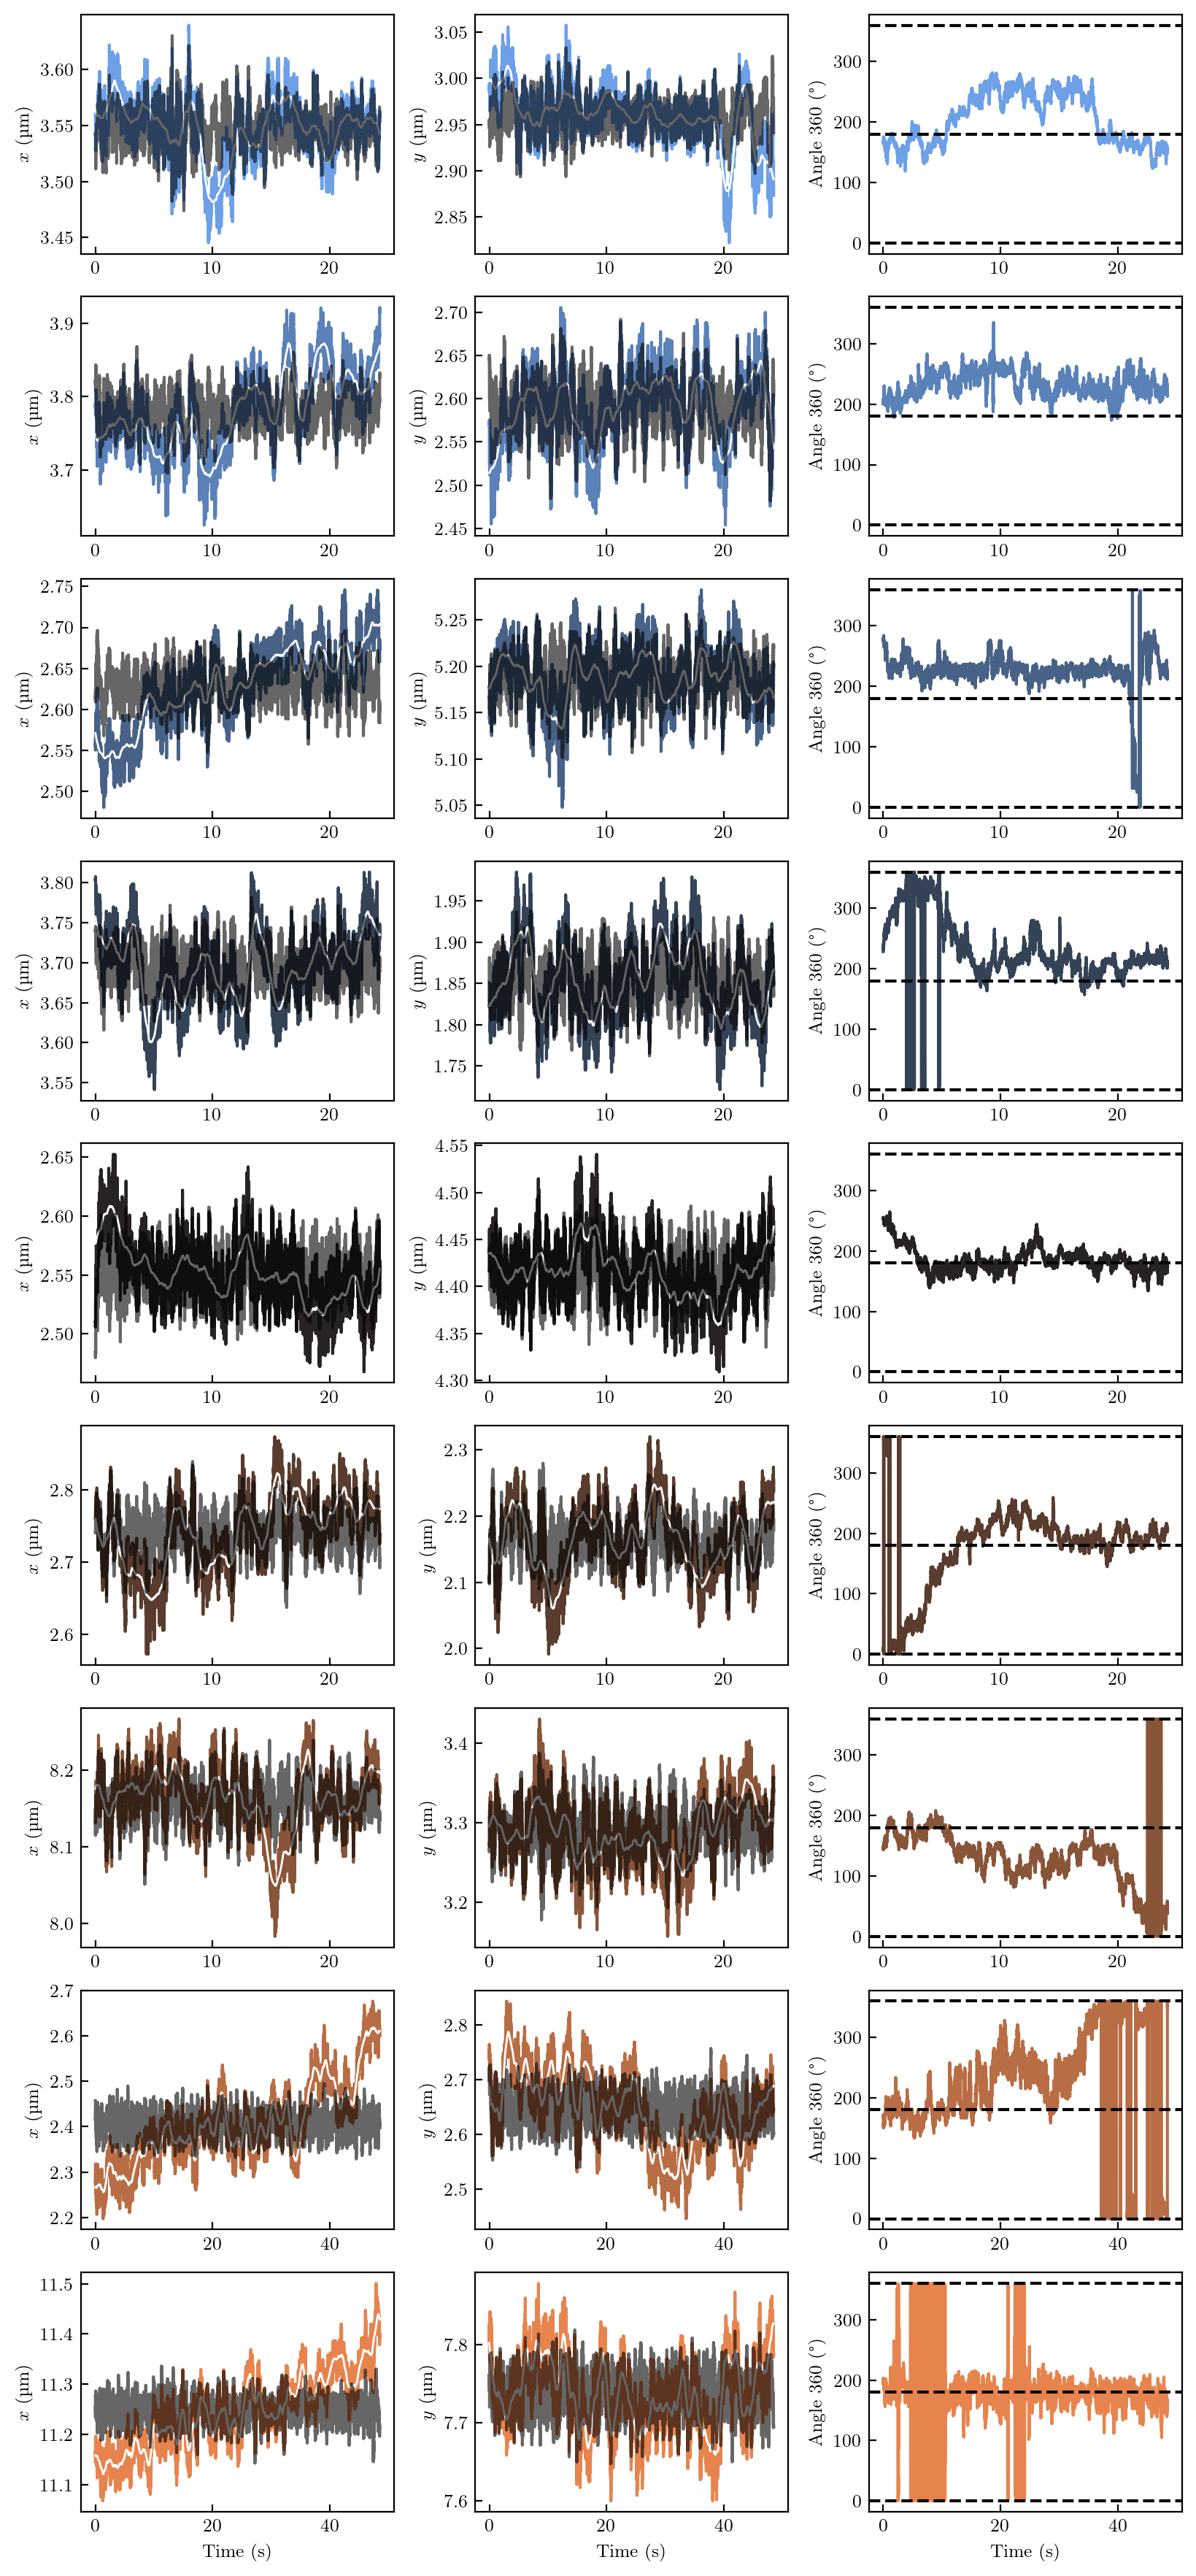

In [34]:
obs00.display_trajectories()

In [35]:
obs00.compute_msds()

In [36]:
obs00.compute_kurtosis()

In [37]:
obs00.compute_msds_theta()

In [38]:
dtimes_Pdx = np.array([0.002, 0.1, 10])
dtimes_Pdtheta = np.array([0.002, 0.1, 10])
obs00.compute_P_displacements(dtimes_Pdx=dtimes_Pdx, dtimes_Pdtheta=dtimes_Pdtheta, nbins=30)

In [39]:
obs10 = Observables(filepaths_1_0, calib, colors=colors, colors_uniform=colors_blue)

Length of the shortest trajectory:
38190

Time step (in s) of all the trajectories:
[0.001 0.001 0.001]


Drifts corrected.


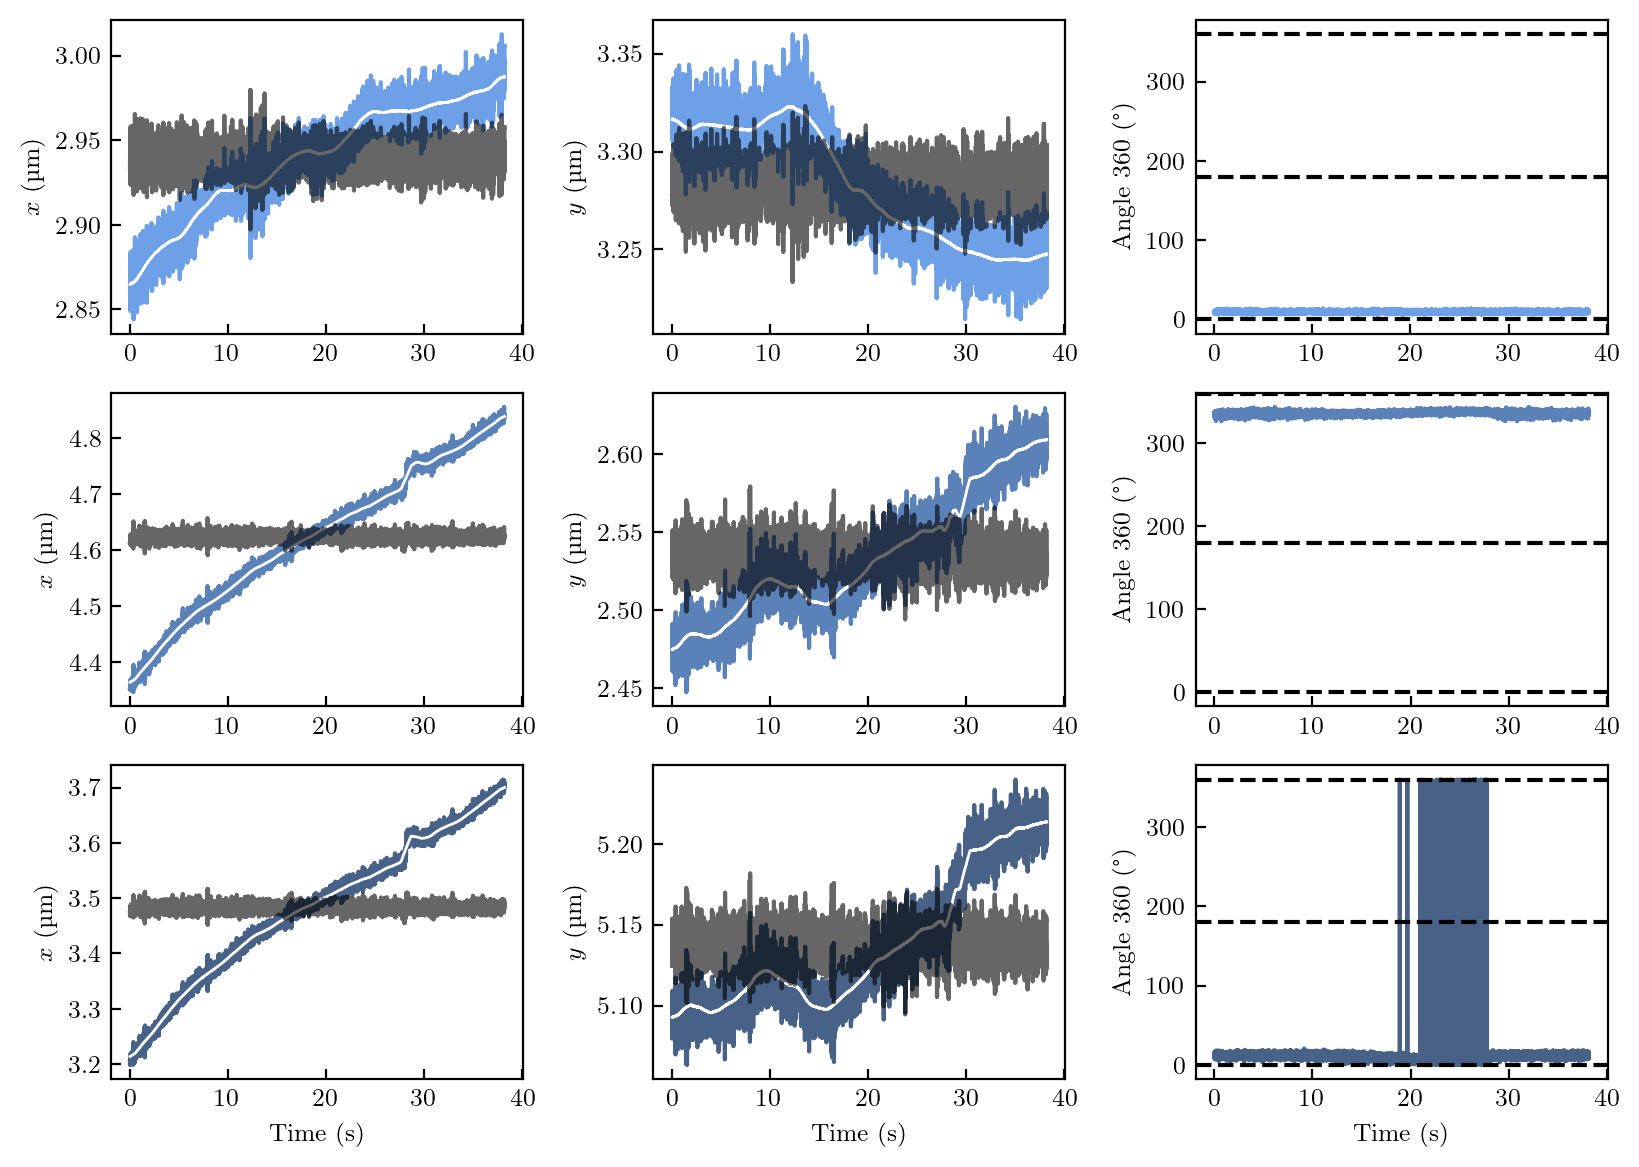

In [40]:
obs10.display_trajectories()

In [41]:
obs10.compute_msds()
obs10.compute_kurtosis()
obs10.compute_msds_theta()
obs10.compute_P_displacements(dtimes_Pdx=dtimes_Pdx, dtimes_Pdtheta=dtimes_Pdtheta, nbins=30)

Length of the shortest trajectory:
43507

Time step (in s) of all the trajectories:
[0.001]
Drifts corrected.


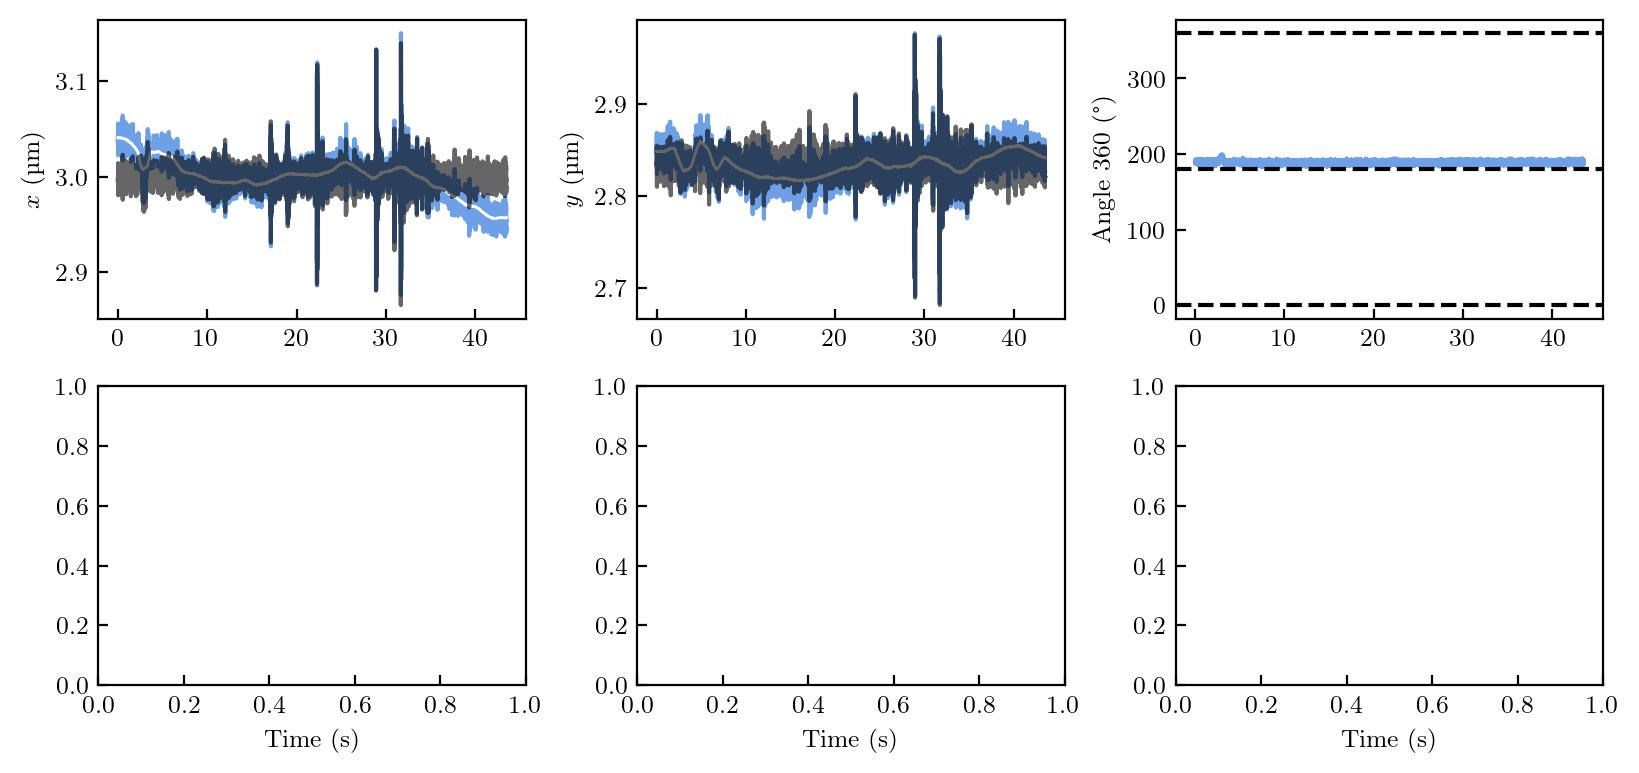

In [42]:
obs20 = Observables(filepaths_2_0, calib, colors=colors, colors_uniform=colors_orange)
obs20.display_trajectories()
obs20.compute_msds()
obs20.compute_kurtosis()
obs20.compute_msds_theta()
obs20.compute_P_displacements(dtimes_Pdx=dtimes_Pdx, dtimes_Pdtheta=dtimes_Pdtheta, nbins=30)

Length of the shortest trajectory:
19561

Time step (in s) of all the trajectories:
[0.001 0.001 0.001 0.001 0.002 0.002]
Drifts corrected.


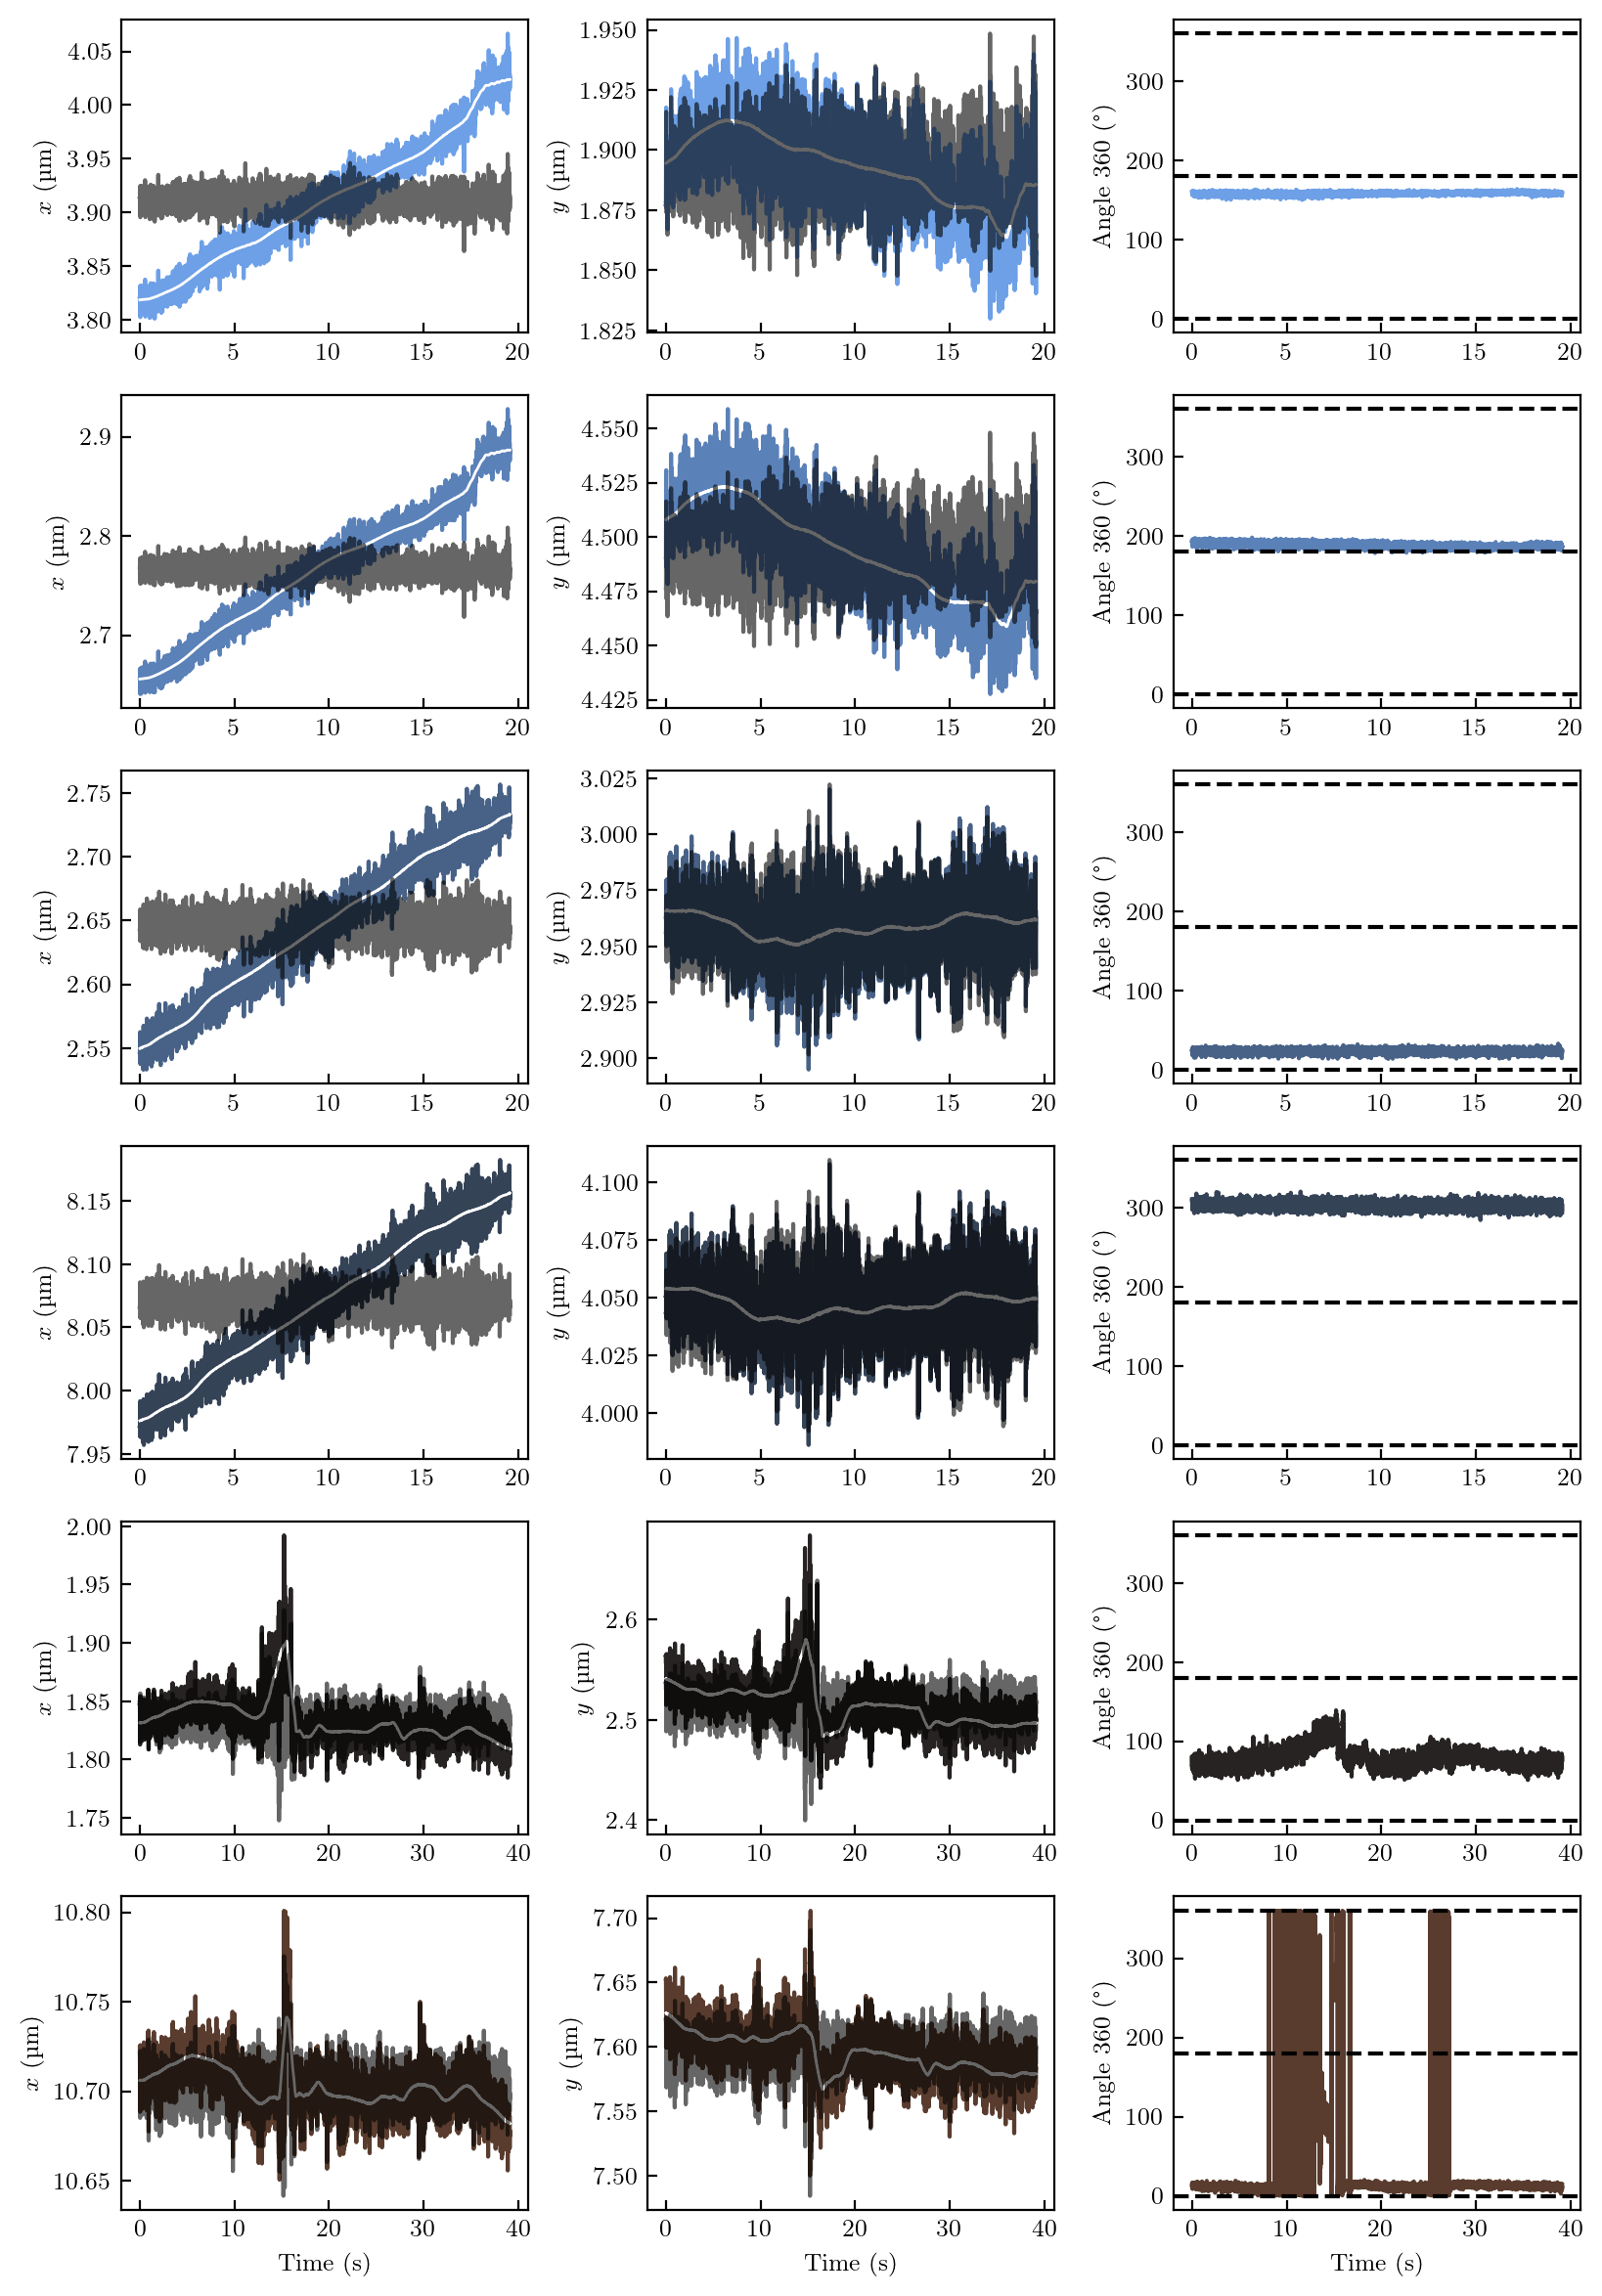

In [43]:
obs30 = Observables(filepaths_3_0, calib, colors=colors, colors_uniform=colors_purple)
obs30.display_trajectories()
obs30.compute_msds()
obs30.compute_kurtosis()
obs30.compute_msds_theta()
obs30.compute_P_displacements(dtimes_Pdx=dtimes_Pdx, dtimes_Pdtheta=dtimes_Pdtheta, nbins=30)

Length of the shortest trajectory:
41624

Time step (in s) of all the trajectories:
[0.001]
Drifts corrected.


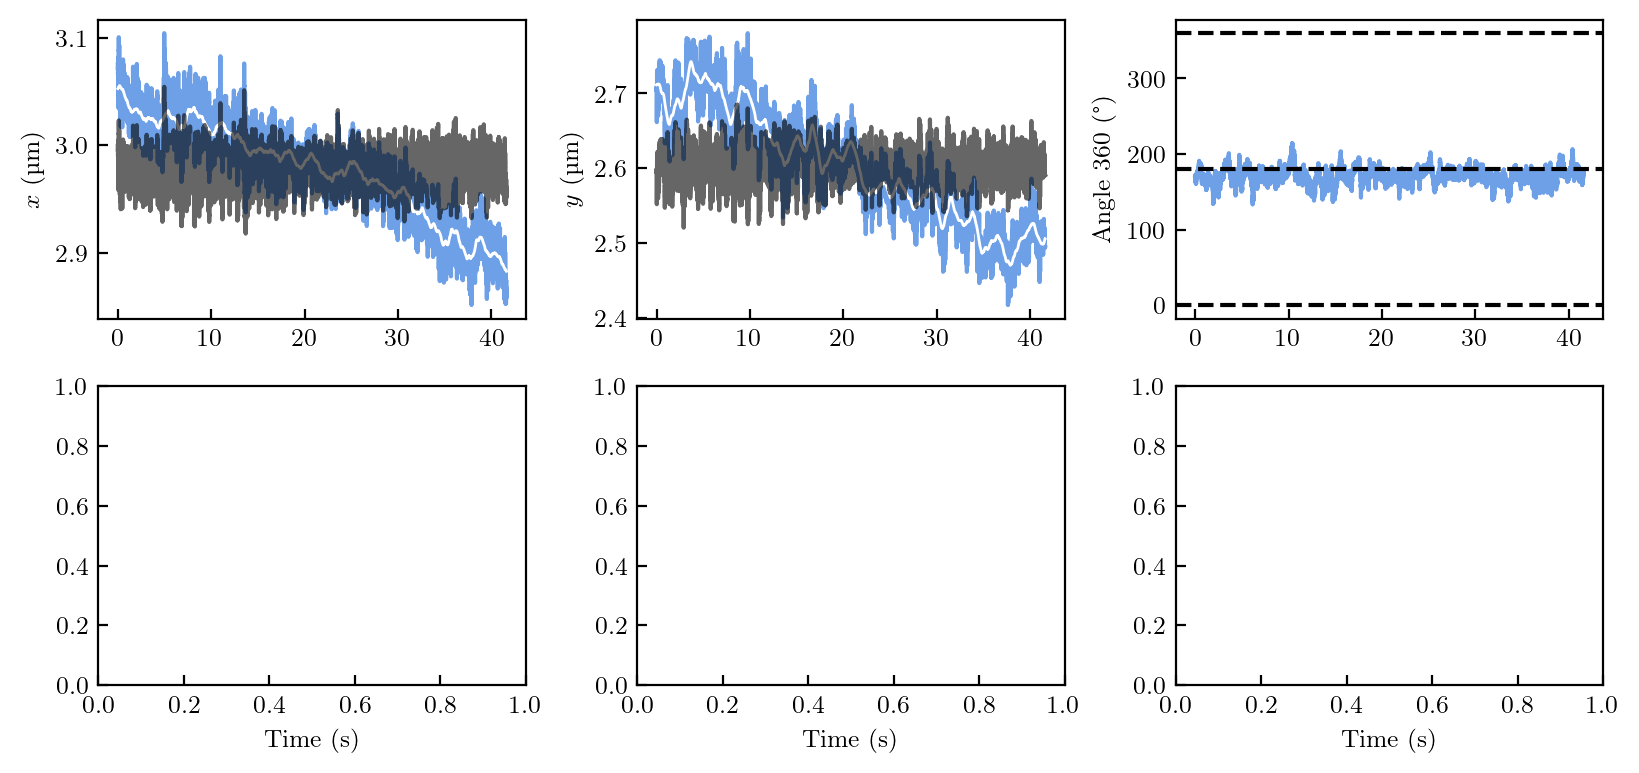

In [44]:
obs40 = Observables(filepaths_4_0, calib, colors=colors, colors_uniform=colors_green)
obs40.display_trajectories()
obs40.compute_msds()
obs40.compute_kurtosis()
obs40.compute_msds_theta()
obs40.compute_P_displacements(dtimes_Pdx=dtimes_Pdx, dtimes_Pdtheta=dtimes_Pdtheta, nbins=30)

Length of the shortest trajectory:
21387

Time step (in s) of all the trajectories:
[0.001]
Drifts corrected.


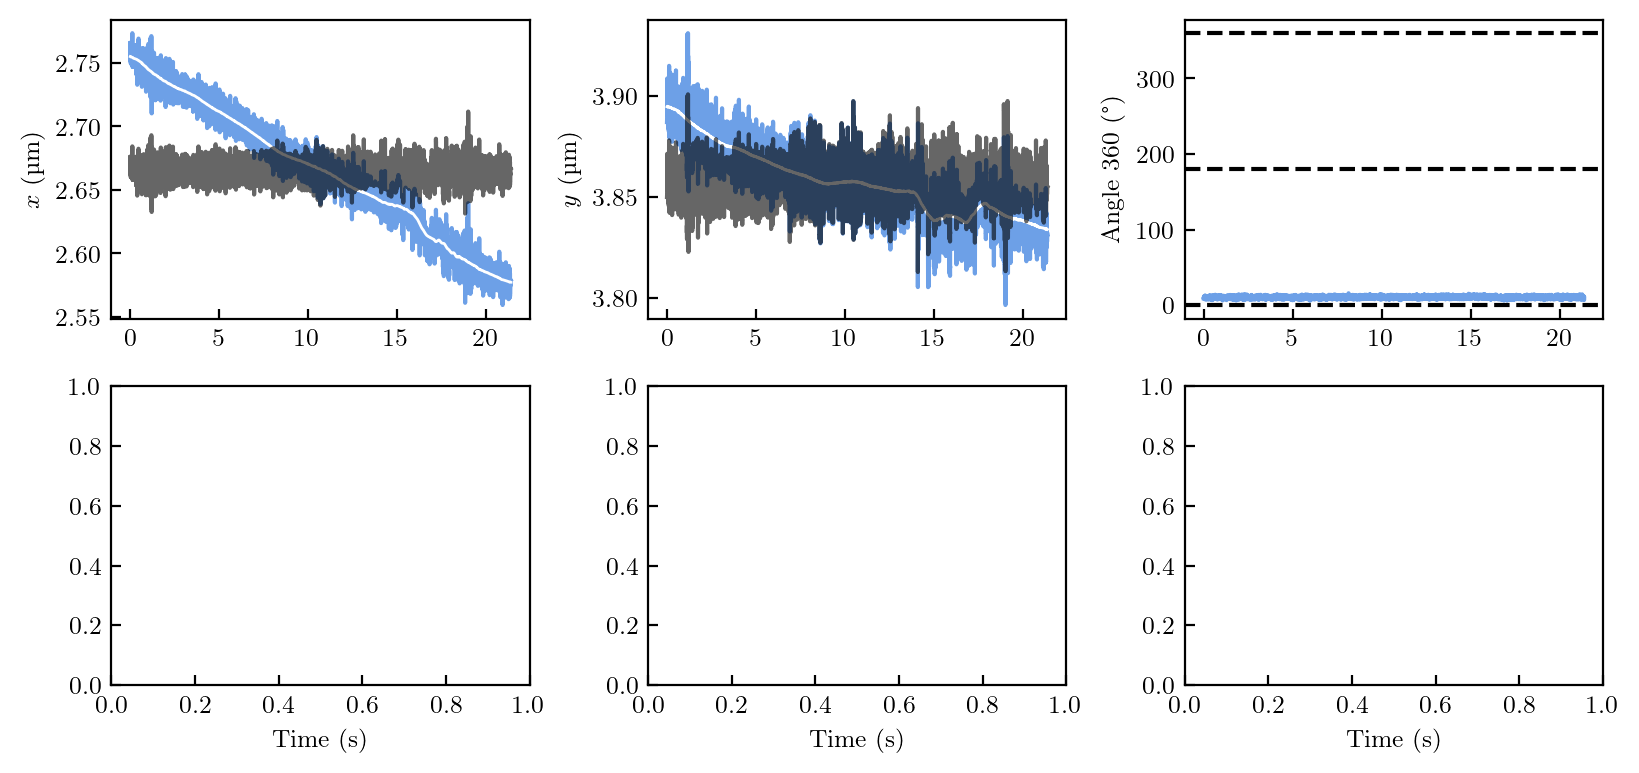

In [45]:
obs50 = Observables(filepaths_5_0, calib, colors=colors, colors_uniform=colors_cyan)
obs50.display_trajectories()
obs50.compute_msds()
obs50.compute_kurtosis()
obs50.compute_msds_theta()
obs50.compute_P_displacements(dtimes_Pdx=dtimes_Pdx, dtimes_Pdtheta=dtimes_Pdtheta, nbins=30)

[6.96458800e-11 3.59272871e-16]


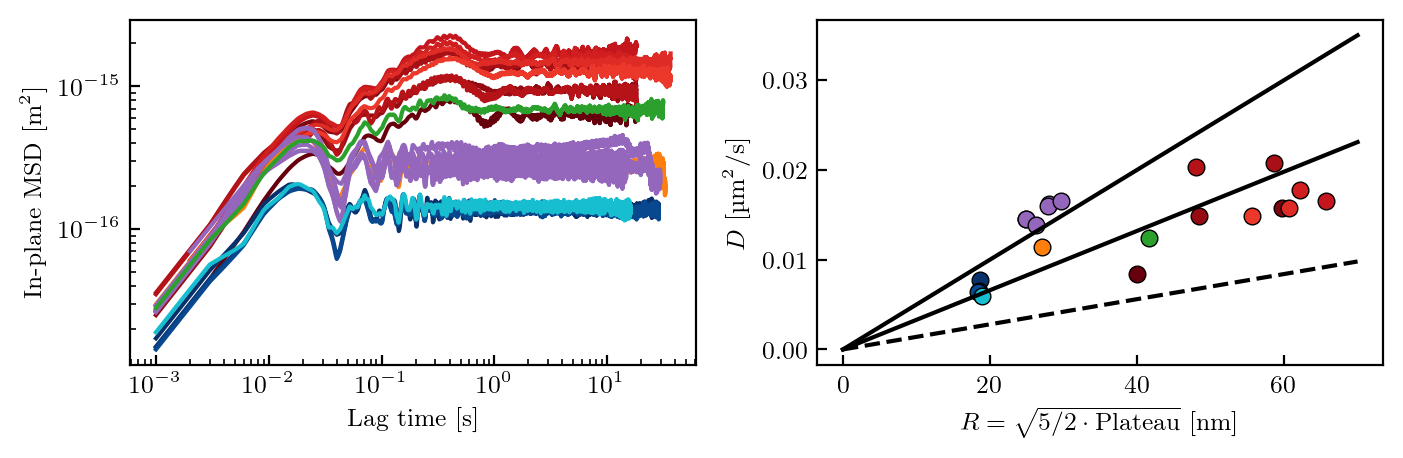

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18/2.54, 6/2.54))
ax, ax2 = axes

# start = 0
# stop = 10000
tplateau = 3 # s
tshort = 0.8e-2 # s

# obs = obs00
# for k in range(obs.Ntraj):
#     dtt = obs.dframes_msd * obs.dts[k]
#     msd = obs.msds[:,k]
#     ax.plot(dtt, msd, ls='-', lw=1.5, c=obs.colors_uniform[k])
#     plateau = np.nanmean(msd[dtt > tplateau])
#     short = np.polyfit(dtt[dtt < tshort], msd[dtt < tshort], 1)
#     D = short[0] / 2
#     ax2.plot(np.sqrt(plateau) * 1e9, D * 1e12, ls='', marker='o', color=obs.colors_uniform[k])

# obs = obs10
# for k in range(obs.Ntraj):
#     dtt = obs.dframes_msd * obs.dts[k]
#     msd = obs.msds[:,k]
#     ax.plot(obs.dframes_msd * obs.dts[k], obs.msds[:,k], ls='-', lw=1.5, c=obs.colors_uniform[k])
#     plateau = np.nanmean(msd[dtt > tplateau])
#     short = np.polyfit(dtt[dtt < tshort], msd[dtt < tshort], 1)
#     D = short[0] / 2
#     ax2.plot(np.sqrt(plateau) * 1e9, D * 1e12, ls='', marker='o', color=obs.colors_uniform[k])

# obs = obs20
# for k in range(obs.Ntraj):
#     dtt = obs.dframes_msd * obs.dts[k]
#     msd = obs.msds[:,k]
#     ax.plot(obs.dframes_msd * obs.dts[k], obs.msds[:,k], ls='-', lw=1.5, c=obs.colors_uniform[k])
#     plateau = np.nanmean(msd[dtt > tplateau])
#     short = np.polyfit(dtt[dtt < tshort], msd[dtt < tshort], 1)
#     D = short[0] / 2
#     ax2.plot(np.sqrt(plateau) * 1e9, D * 1e12, ls='', marker='o', color=obs.colors_uniform[k])

plateaus = []
Rs = []
Ds = []
mean_rs = []

for obs in [obs00, obs10, obs20, obs30, obs40, obs50]:
    for k in range(obs.Ntraj):
        dtt = obs.dframes_msd * obs.dts[k]
        msd = obs.msds[:,k]
        ax.plot(obs.dframes_msd * obs.dts[k], obs.msds[:,k], ls='-', lw=1.5, c=obs.colors_uniform[k])
        plateau = np.nanmean(msd[dtt > tplateau])
        R = sqrt(5 / 2 * plateau)
        short = np.polyfit(dtt[dtt < tshort], msd[dtt < tshort], 1)
        # short = np.polyfit(dtt[:5], msd[:5], 1)
        D = short[0] / 2
        ax2.plot(R * 1e9, D * 1e12, ls='', marker='o', color=obs.colors_uniform[k])
        plateaus.append(plateau)
        Rs.append(R)
        Ds.append(D)

        x = obs.datac[:, 1, k]
        y = obs.datac[:, 2, k]
        r = np.sqrt((x-np.nanmean(x))**2 + (y-np.nanmean(y))**2)
        mean_rs.append(np.nanmean(r))

# plateaus, Rs, Ds = zip(*sorted(zip(plateaus, Rs, Ds)))

plateaus, Rs, Ds, mean_rs = np.array(plateaus), np.array(Rs), np.array(Ds), np.array(mean_rs)

linearfit = np.polyfit(np.sqrt(Rs), Ds, 1)
print(linearfit)

xtheory = np.linspace(0, 70, 100) * 1e-9
# ax2.plot(xtheory * 1e9, np.polyval(linearfit[::], xtheory) * 1e12, ls='-', c='k', lw=1.5)
ax2.plot(xtheory * 1e9, 0.5e-6 * xtheory * 1e12, ls='-', c='k', lw=1.5)
ax2.plot(xtheory * 1e9, 0.33e-6 * xtheory * 1e12, ls='-', c='k', lw=1.5)
ax2.plot(xtheory * 1e9, 0.14e-6 * xtheory * 1e12, ls='--', c='k', lw=1.5)

# ax.set_ylabel(r'$\langle \left( \Delta x -  \langle \Delta x \rangle \right) ^2 \rangle$ (m$^2$)')
ax.set_ylabel(r'In-plane MSD [m$^2$]')
ax.set_xlabel('Lag time [s]')
ax.set_xscale('log')
ax.set_yscale('log')

ax2.set_xlabel(r'$R = \sqrt{\mathrm{5/2 \cdot Plateau}}$ [nm]')
ax2.set_ylabel(r'$D$ [\textmu m$^2$/s]')

plt.tight_layout()
plt.show()

In [72]:
# fig.savefig('MSDs_sams_exp.pdf', transparent=True)

In [73]:
a = 1.23e-6

import numpy as np

4e-21 / (6 * np.pi * 1e-3 * a) / a

1.402647833889839e-07

In [74]:
72 * calib / 2 * 1e6

1.26

In [75]:
m = 5.26 * 1e3 * (2 * a) ** 3
m

7.830528336000003e-14

In [76]:
w = 25

spring = m * w**2
spring

4.8940802100000015e-11

In [77]:
spring * 50e-9

2.4470401050000006e-18

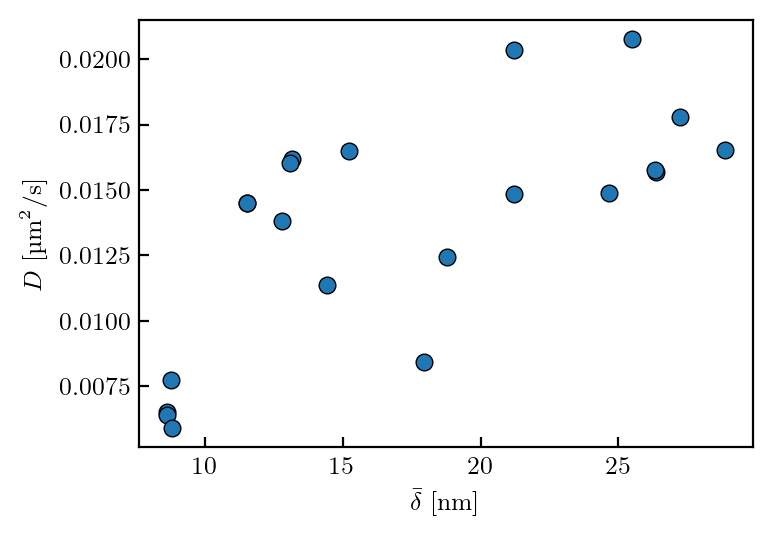

In [83]:
fig, ax = plt.subplots(1, 1, figsize=(10/2.54, 7/2.54))

ax.plot((Rs - mean_rs) * 1e9, Ds * 1e12, ls='', marker='o', c='tab:blue')

ax.set_xlabel(r'$\bar{\delta} $ [nm]')
ax.set_ylabel(r'$D$ [\textmu m$^2$/s]')

plt.tight_layout()
plt.show()

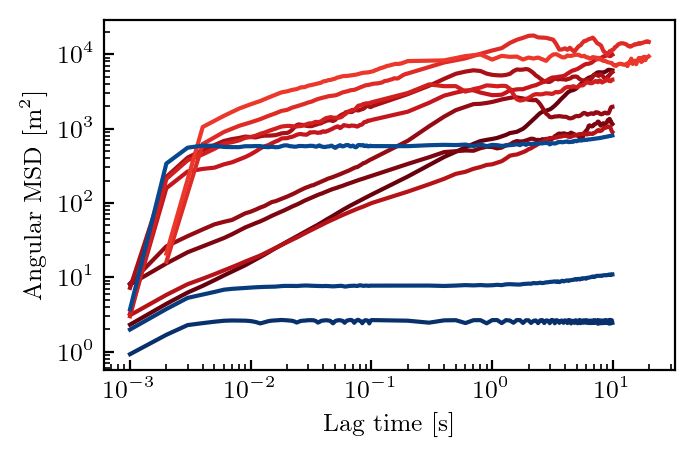

In [54]:
fig, ax = plt.subplots(1, 1, figsize=(9/2.54, 6/2.54))

# start = 0
# stop = 10000

obs = obs00
for k in range(obs.Ntraj):
    ax.plot(obs.dframes_msd_theta * obs.dts[k], obs.msds_theta[:,k], ls='-', lw=1.5, c=obs.colors_uniform[k])


obs = obs10
plateaux10 = np.zeros(obs10.Ntraj)
for k in range(obs.Ntraj):
    ax.plot(obs.dframes_msd_theta * obs.dts[k], obs.msds_theta[:,k], ls='-', lw=1.5, c=obs.colors_uniform[k])

ax.set_ylabel(r'Angular MSD [m$^2$]')
ax.set_xlabel('Lag time [s]')
ax.set_xscale('log')
ax.set_yscale('log')

plt.tight_layout()
plt.show()

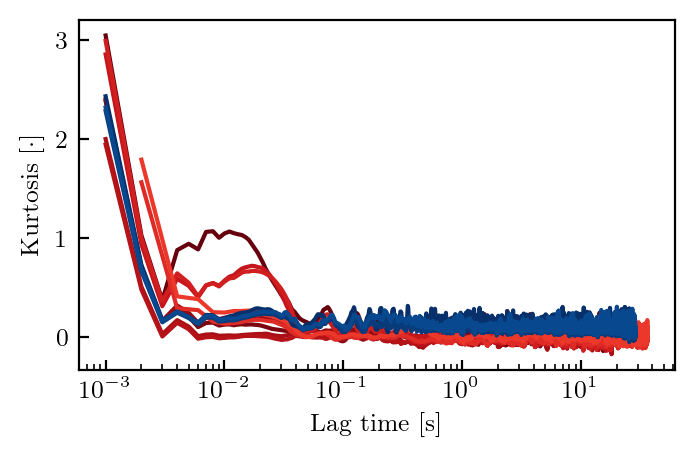

In [55]:
fig, ax = plt.subplots(1, 1, figsize=(9/2.54, 6/2.54))

# start = 0
# stop = 10000

obs = obs00
for k in range(obs.Ntraj):
    ax.plot(obs.dframes_msd * obs.dts[k], obs.kurtosis[:,k], ls='-', lw=1.5, c=obs.colors_uniform[k])

obs = obs10
for k in range(obs.Ntraj):
    ax.plot(obs.dframes_msd * obs.dts[k], obs.kurtosis[:,k], ls='-', lw=1.5, c=obs.colors_uniform[k])

ax.set_ylabel(r'Kurtosis [$\cdot$]')
ax.set_xlabel('Lag time [s]')
ax.set_xscale('log')
# ax.set_yscale('log')

plt.tight_layout()
plt.show()

In [56]:
# fig.savefig('kurtosis.pdf')

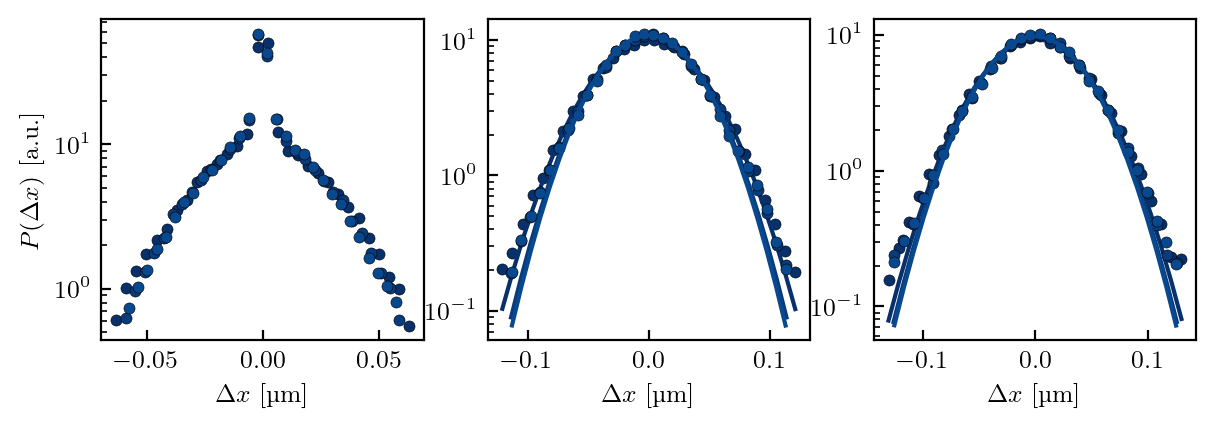

In [57]:
fig, axes = plt.subplots(1, 3, figsize=(5*3/2.54, 5/2.54))

obs = obs10
for k in range(3):

    for j, d in enumerate(dtimes_Pdx[::]):

        bins, prob = obs.Pdx[str(k)][str(d)][0,:], obs.Pdx[str(k)][str(d)][1,:]

        axes[j].plot(bins * 1e6, prob * 1e-6, ls='', marker='o', color=obs.colors_uniform[k], mew=0.2, ms=4)

        if j != 0:
            popt, _ = curve_fit(gaussian, bins, prob, p0=[1e-6, 1e6])
            axes[j].plot(bins*1e6, gaussian(bins, *popt)*1e-6, ls='-', color=obs.colors_uniform[k], lw=1.5)

for j, ax in enumerate(axes[:]):
    ax.set_xlabel(r'$\Delta x$ [\textmu m]')
    ax.set_yscale('log')
axes[0].set_ylabel(r'$P(\Delta x)$ [a.u.]')

plt.tight_layout(pad=0.1)
plt.show()

In [147]:
# fig.savefig('example_P_displacements.pdf', transparent=True)

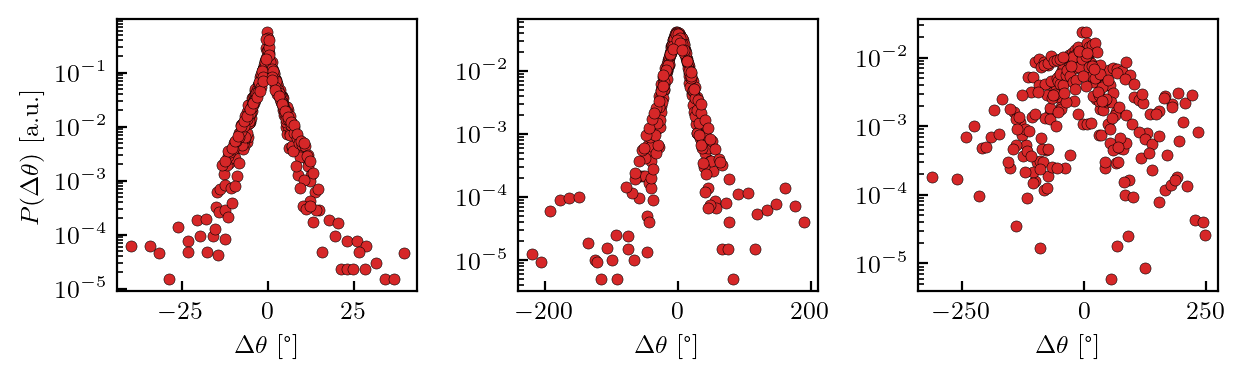

In [150]:
fig, axes = plt.subplots(1, 3, figsize=(16/2.54, 5/2.54))

obs = obs00
for k in range(obs.Ntraj):
    
    for j, d in enumerate(dtimes_Pdtheta[0:3:1]):
        if j <= 2:
            bins, prob = obs.Pdthetas[str(k)][str(d)][0,:], obs.Pdthetas[str(k)][str(d)][1,:]
            axes[j].plot(bins, prob, ls='', marker='o', color=obs.colors_uniform[k], mew=0.2, ms=4)

obs = obs10
for k in range(obs.Ntraj):

    for j, d in enumerate(dtimes_Pdtheta[0:3:1]):
        bins, prob = obs.Pdthetas[str(k)][str(d)][0,:], obs.Pdthetas[str(k)][str(d)][1,:]
        # axes[j].plot(bins, prob, ls='', marker='o', color=obs.colors_uniform[k], mew=0.2, ms=4)

# binsth = np.linspace(-110, 100, 100)
# test = np.exp(- np.abs(binsth) / )
# axes[1].plot()

for j, ax in enumerate(axes[:]):
    ax.set_xlabel(r'$\Delta \theta$ [°]')
    ax.set_yscale('log')
axes[0].set_ylabel(r'$P(\Delta \theta)$ [a.u.]')

plt.tight_layout()
plt.show()

In [ ]:
# fig.savefig('P_dtheta_salt.pdf', transparent=True)

In [46]:
def Cxy(x: np.ndarray, y:np.ndarray, lags: np.ndarray=np.arange(1,10,1), retrieve_mean: bool=False):
    if retrieve_mean:
        x = x - np.nanmean(x)
        y = y - np.nanmean(y)
    res = np.zeros_like(lags) * np.nan
    for i, d in enumerate(lags):
        res[i] = np.nanmean(x[:-d] * y[d:])
    return res

def Cxy_fft(x: np.ndarray, y:np.ndarray, retrieve_mean: bool=False):
    if retrieve_mean:
        x = x - np.mean(x)
        y = y - np.mean(y)
    N = len(x)
    fx = np.fft.rfft(x, n=2*N)
    fy = np.fft.rfft(y, n=2*N)
    res = np.fft.irfft(fx * np.conj(fy))[:N]
    # res /= (N - np.arange(N)) # to unbias, but I don't understand
    return res

# def Cdxdy(x: np.ndarray, y:np.ndarray, lags: np.ndarray=np.arange(1,10,1), retrieve_mean: bool=False):
#     res = np.zeros_like(lags) * np.nan
#     if retrieve_mean:
#         for i, d in enumerate(lags):
#             dx = x[d:-d] - x[:-int(2*d)]
#             dy = y[int(2*d):] - y[d:-d]
#             res[i] = np.nanmean((dx - np.nanmean(dx)) * (dy - np.nanmean(dy)))
#     else:
#         for i, d in enumerate(lags):
#             dx = x[d:-d] - x[:-int(2*d)]
#             dy = y[int(2*d):] - y[d:-d]
#             res[i] = np.nanmean(dx * dy)
#     return res

def Cdxdy(x: np.ndarray, y:np.ndarray, lags: np.ndarray=np.arange(1,10,1), disp: int=1, retrieve_mean: bool=False):
    dx = x[disp:] - x[:-disp]
    dy = y[disp:] - y[:-disp]
    return Cxy(x=dx, y=dy, lags=lags, retrieve_mean=retrieve_mean)

def Cdxdy_fft(x: np.ndarray, y:np.ndarray, disp: int=1, retrieve_mean: bool=False):
    dx = x[disp:] - x[:-disp]
    dy = y[disp:] - y[:-disp]
    return Cxy_fft(x=dx, y=dy, retrieve_mean=retrieve_mean)

In [47]:
dframes = np.concatenate((np.arange(1, 100, 1), np.arange(100, 10000, 1)))
dtimes = dframes * dt

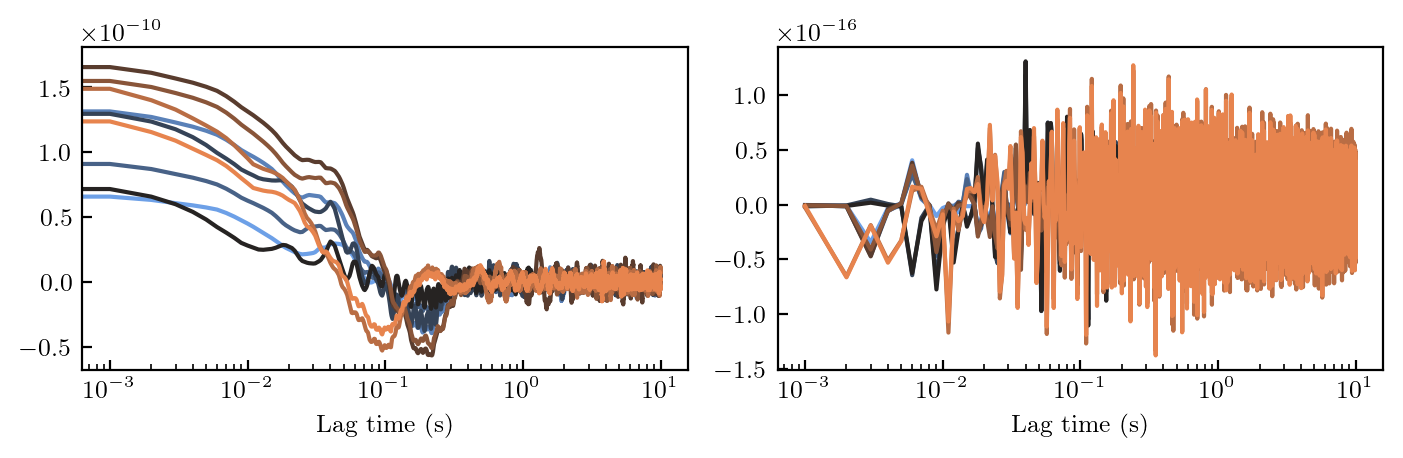

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(18/2.54, 6/2.54))

for i, k in enumerate(indexes):
    
    x = datas[:, 1, k]
    y = datas[:, 2, k]
    theta = datas[:, 3, k]

    xd = x #signal.detrend(x, type='linear')

    # cxx = Cxy(x, y, lags=np.arange(len(x)), retrieve_mean=True)
    cxy = Cxy_fft(xd, xd, retrieve_mean=True)
    # cxy = autocorrelation_biased(x)
    cdxdtheta = Cdxdy(xd, xd, dframes[:], disp=1, retrieve_mean=True)

    axes[0].plot(np.arange(len(x))[:10000] * dt, cxy[:10000], ls='-', marker='', color=colors[k], mew=0.2)
    axes[1].plot(dtimes[:], cdxdtheta, ls='-', marker='', color=colors[k], mew=0.1, ms=3)

# axes[0].set_ylabel(r'$\langle \Delta x \rangle$ (m)')
axes[0].set_xlabel('Lag time (s)')
axes[0].set_xscale('log')
# axes[0].set_yscale('log')
# axes[1].set_ylabel(r'$\langle \left( \Delta x -  \langle \Delta x \rangle \right) ^2 \rangle$ (m$^2$)')
axes[1].set_xlabel('Lag time (s)')
axes[1].set_xscale('log')
# axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

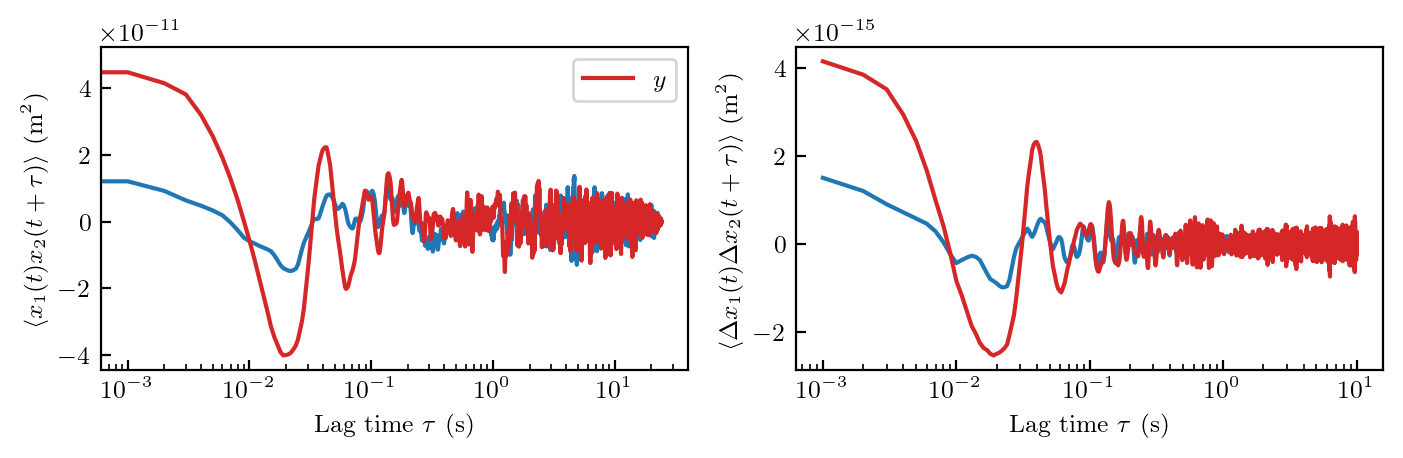

In [49]:
i1 = 1
i2 = 2

x1 = datas[:,1,i1]
y1 = datas[:,2,i1]
x2 = datas[:,1,i2]
y2 = datas[:,2,i2]

cx1x2 = Cxy_fft(x1, x2, retrieve_mean=True)
cy1y2 = Cxy_fft(y1, y2, retrieve_mean=True)

cdx1dx2 = Cdxdy(x1, x2, lags=dframes, disp=10, retrieve_mean=True)
cdy1dy2 = Cdxdy(y1, y2, lags=dframes, disp=10, retrieve_mean=True)
# cdx1dx2 = Cdxdy(x1, x2, lags=dframes, retrieve_mean=True)
# cdy1dy2 = Cdxdy(y1, y2, lags=dframes, retrieve_mean=True)

fig, axes = plt.subplots(1, 2, figsize=(18/2.54, 6/2.54))

axes[0].plot(np.arange(len(x1)) * dt, cx1x2, ls='-', marker='', color='tab:blue', mew=0.2)
axes[0].plot(np.arange(len(y1)) * dt, cy1y2, ls='-', marker='', color='tab:red', mew=0.2, label=r'$y$')

axes[1].plot(dtimes, cdx1dx2, ls='-', marker='', color='tab:blue', mew=0.2)
axes[1].plot(dtimes, cdy1dy2, ls='-', marker='', color='tab:red', mew=0.2)

axes[0].legend()

axes[0].set_ylabel(r'$\langle x_1(t) x_2(t+\tau) \rangle$ (m$^2$)')
axes[0].set_xlabel(r'Lag time $\tau$ (s)')
axes[0].set_xscale('log')
# axes[0].set_yscale('log')
axes[1].set_ylabel(r'$\langle \Delta x_1(t) \Delta x_2(t+\tau) \rangle$ (m$^2$)')
axes[1].set_xlabel(r'Lag time $\tau$ (s)')
axes[1].set_xscale('log')
# axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

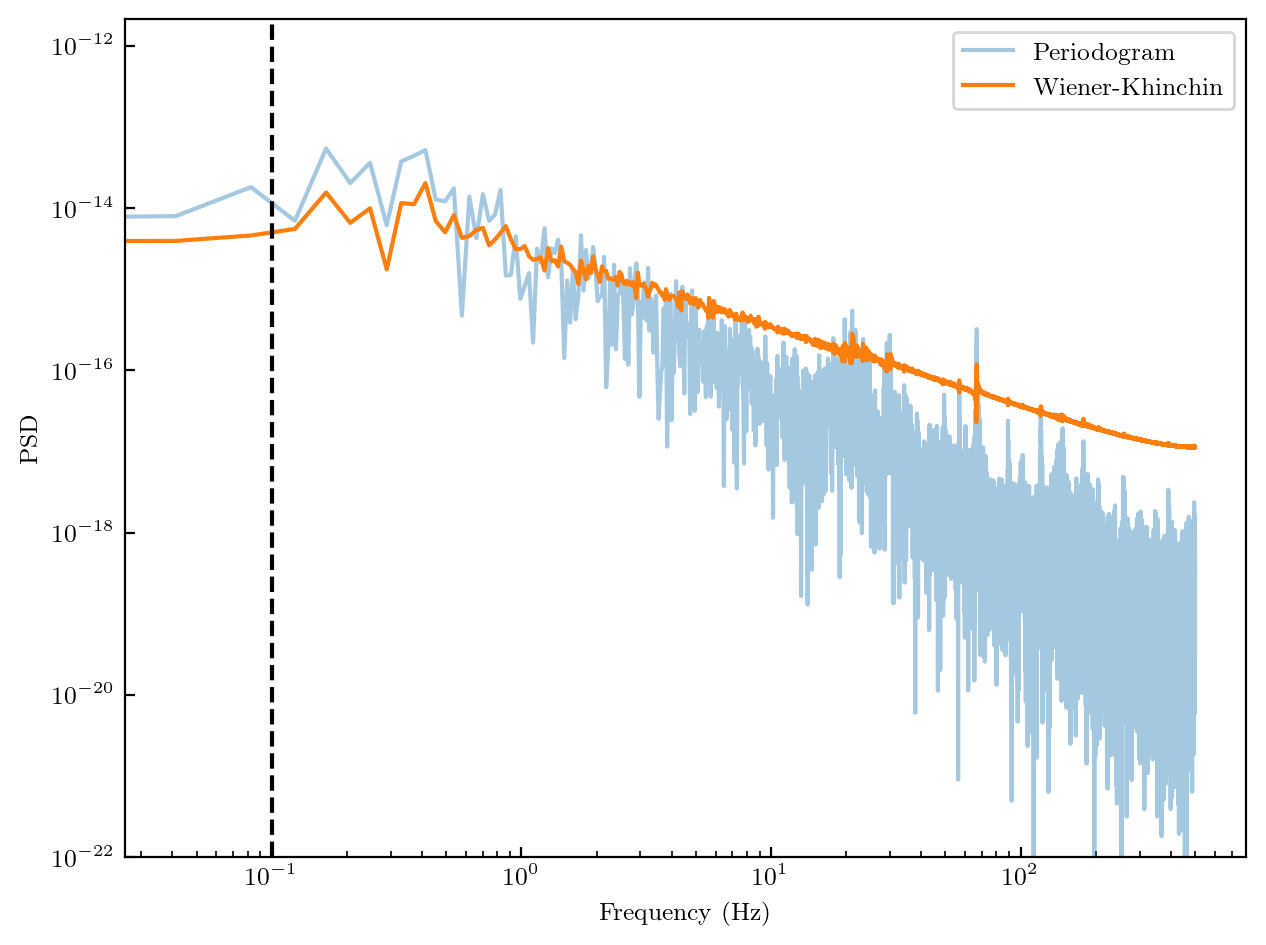

In [78]:


# ── Wiener-Khinchin (via autocorrelation) ──────────────────────────────
def autocorrelation_biased(a):
    a = a - np.mean(a)
    N = len(a)
    f = np.fft.rfft(a, n=2*N)
    acf = np.fft.irfft(f * np.conj(f))[:N]
    acf /= N  # divide by N instead of N-lag
    return acf
    
x_detrended = x #signal.detrend(x, type='linear')
acf = autocorrelation_biased(x_detrended)

def compute_psd(a, dt):
    x_detrended = x #signal.detrend(x, type='linear')
    acf = acf = autocorrelation_biased(x_detrended)
    psd_wk = np.fft.rfft(acf) * dt
    freqs_wk = np.fft.rfftfreq(len(acf), d=dt)
    return freqs_wk, psd_wk

# ── 3. Periodogram ────────────────────────────────────────────────────────
freqs_pgram, psd_pgram = signal.periodogram(x, fs=1/dt, scaling='density')

# ── Plot ──────────────────────────────────────────────────────────────────

plt.figure()
plt.loglog(freqs_pgram, psd_pgram, alpha=0.4, label='Periodogram')
plt.plot(freqs_wk, np.abs(psd_wk), label='Wiener-Khinchin')
# plt.semilogy(freqs_welch, psd_welch, lw=2, label='Welch')
plt.axvline(x=1/dt/window, ls='--', color='k')
plt.xlabel('Frequency (Hz)')
plt.ylabel('PSD')
plt.legend()
plt.ylim([1e-22, None])
plt.tight_layout()
plt.show()

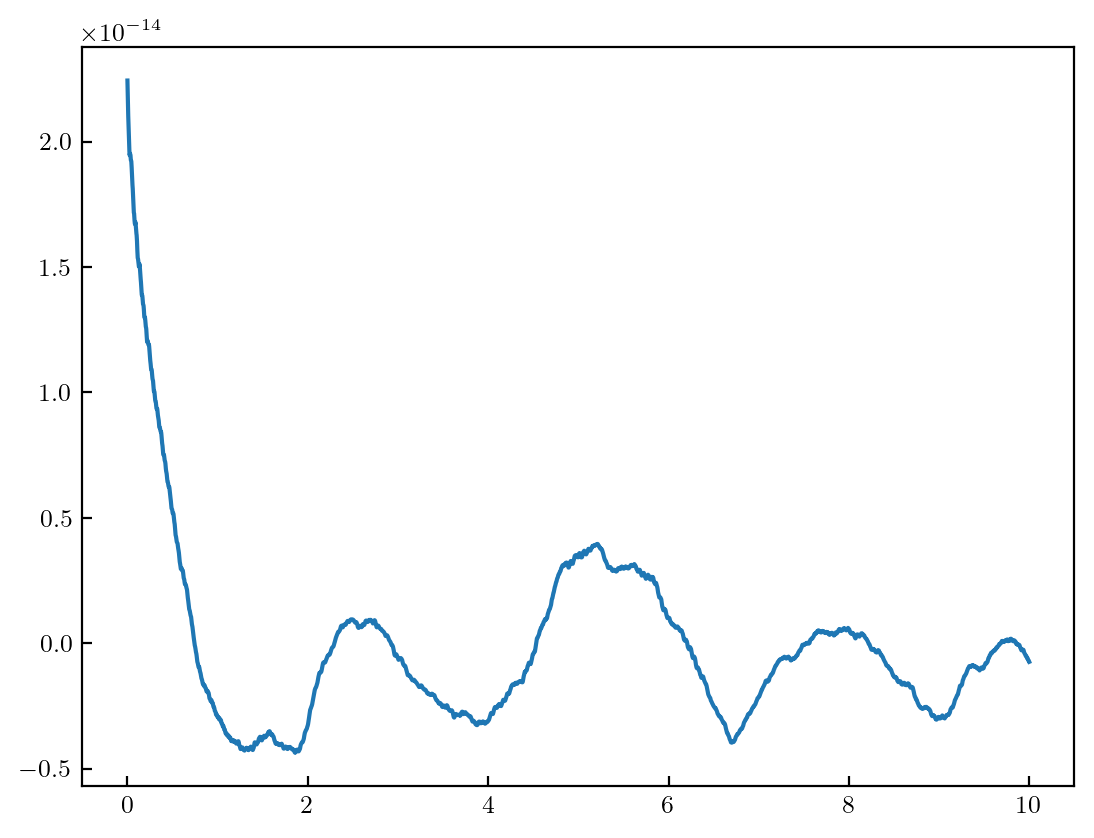

In [79]:
plt.plot(np.arange(len(acf))[:10000]*dt, acf[:10000])

In [80]:
print(np.mean(x))

-5.053843574977739e-09


In [652]:
# plt.plot(x-np.nanmean(x))
# plt.plot(x_detrended)